# Hitmakers — Full Model Pipeline & Comparison

Six ensemble/boosting models: AdaBoost Linear · AdaBoost Tree · Random Forest · LightGBM · XGBoost · CatBoost

Per-model pipeline:
1. Full-feature Optuna (penalized: AUC − λ×gap) → params_full
2. Cross-validated feature importance: CV SHAP (tree models) / CV permutation importance (AdaBoost Linear)
3. Genre consolidation: SHAP models keep genres above mean genre importance; perm models keep importance > 0; rest merged into artist_genre_other
4. Forward selection on consolidated feature set (centrality included in pool, ordered by Step 2 importance)
5. Two candidates: n_peak (max CV AUC) + n_gap (min overfit gap) → Optuna re-tune on both → winner by penalized score (AUC − λ×gap); MIN_N=5 floor prevents pathologically sparse selection
6. Centrality ablation: post-hoc check on winning feature set — drop any centrality subset that improves raw CV AUC (following ml_sandbox_18_catboost)
7. Final model evaluation (ROC, confusion matrix, calibration, PR, lift curve)
8. OOF threshold tuning (leakage-safe, using out-of-fold predictions)

Cross-model section: metrics table, CV AUC ± std bar chart, lift overlay, disagreement table, SHAP feature importance heatmaps.

In [2]:
import shap
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.ensemble import AdaBoostClassifier, RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import SGDClassifier
from sklearn.dummy import DummyClassifier
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.inspection import permutation_importance, PartialDependenceDisplay
from sklearn.metrics import (
    roc_auc_score, log_loss, brier_score_loss,
    accuracy_score, f1_score, precision_score, recall_score,
    confusion_matrix, classification_report,
    roc_curve, precision_recall_curve, average_precision_score,
    ConfusionMatrixDisplay,
)
from sklearn.calibration import calibration_curve
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier
import optuna
from optuna.samplers import TPESampler
optuna.logging.set_verbosity(optuna.logging.WARNING)


In [3]:
# LAM: penalty in Optuna objective (AUC - LAM * overfit_gap).
# Willing to sacrifice LAM units of AUC to reduce gap by 1.
# Robustness across lambda values is checked in Step 7.
LAM             = 0.3
N_SPLITS        = 5
N_TRIALS_FULL   = 30
N_TRIALS_RETUNE = 30
RANDOM_STATE    = 42

MODEL_NAMES = [
    'AdaBoost Linear',
    'AdaBoost Tree',
    'Random Forest',
    'LightGBM',
    'XGBoost',
    'CatBoost',
]

# SGDClassifier (AdaBoost Linear base) is scale-sensitive.
# Tree-based models are scale-invariant.
MODEL_NEEDS_SCALER = {name: (name == 'AdaBoost Linear') for name in MODEL_NAMES}

In [4]:
# years_through_first_top_20_hit is stored as CSV index — reset_index() recovers it.
# 80/20 stratified split. No separate validation set needed:
# Optuna + 5-fold CV handles hyperparameter selection without a held-out val set,
# and our small dataset (759 artists) benefits from maximising training data.

df = pd.read_csv('df_artists_final.csv', index_col=0).reset_index()
X  = df.drop(columns=['top_20_hitmaker'])
y  = df['top_20_hitmaker']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)
skf = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=RANDOM_STATE)

print(f'Full dataset:  {df.shape}')
print(f'Train / Test:  {X_train.shape[0]} / {X_test.shape[0]}')
print(f'Features:      {X.shape[1]}')
print(f'Class balance (full):')
print(y.value_counts(normalize=True).round(3).rename({0.0: 'One-hit Wonder', 1.0: 'Hitmaker'}))

Full dataset:  (759, 27)
Train / Test:  607 / 152
Features:      26
Class balance (full):
top_20_hitmaker
One-hit Wonder    0.568
Hitmaker          0.432
Name: proportion, dtype: float64


## EDA

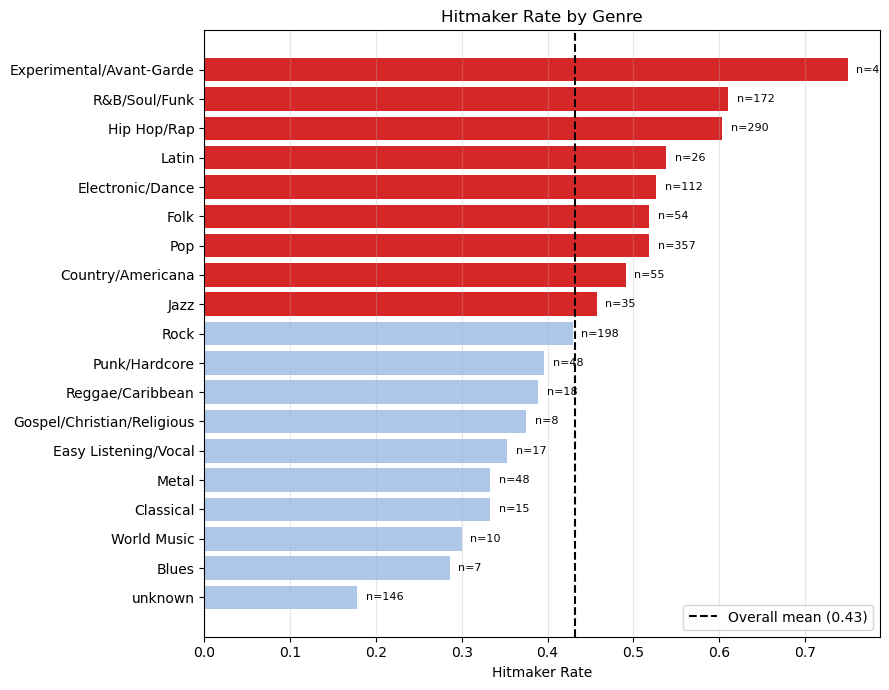

In [5]:
# Hitmaker rate per genre — shows which genres are over- or under-represented.
# Red bars: genres where hitmaker rate exceeds the overall mean.
# Motivates genre consolidation in Step 3: high-signal genres kept separately,
# low-signal genres merged into a single 'other' flag.

genre_cols   = [c for c in X.columns if c.startswith('artist_genre_')]
overall_mean = y.mean()
rates = []
for col in genre_cols:
    mask = df[col] == 1
    if mask.sum() == 0:
        continue
    rates.append({
        'Genre': col.replace('artist_genre_', ''),
        'Hitmaker Rate': df.loc[mask, 'top_20_hitmaker'].mean(),
        'N': mask.sum(),
    })

df_rates = pd.DataFrame(rates).sort_values('Hitmaker Rate', ascending=True)
fig, ax  = plt.subplots(figsize=(9, 7))
colors   = ['#d62728' if r > overall_mean else '#aec7e8' for r in df_rates['Hitmaker Rate']]
bars     = ax.barh(df_rates['Genre'], df_rates['Hitmaker Rate'], color=colors)
ax.axvline(overall_mean, color='black', linestyle='--', lw=1.5,
           label=f'Overall mean ({overall_mean:.2f})')
for bar, n in zip(bars, df_rates['N']):
    ax.text(bar.get_width() + 0.01, bar.get_y() + bar.get_height() / 2,
            f'n={n}', va='center', fontsize=8)
ax.set_xlabel('Hitmaker Rate')
ax.set_title('Hitmaker Rate by Genre')
ax.legend(); ax.grid(axis='x', alpha=0.3)
plt.tight_layout(); plt.show()

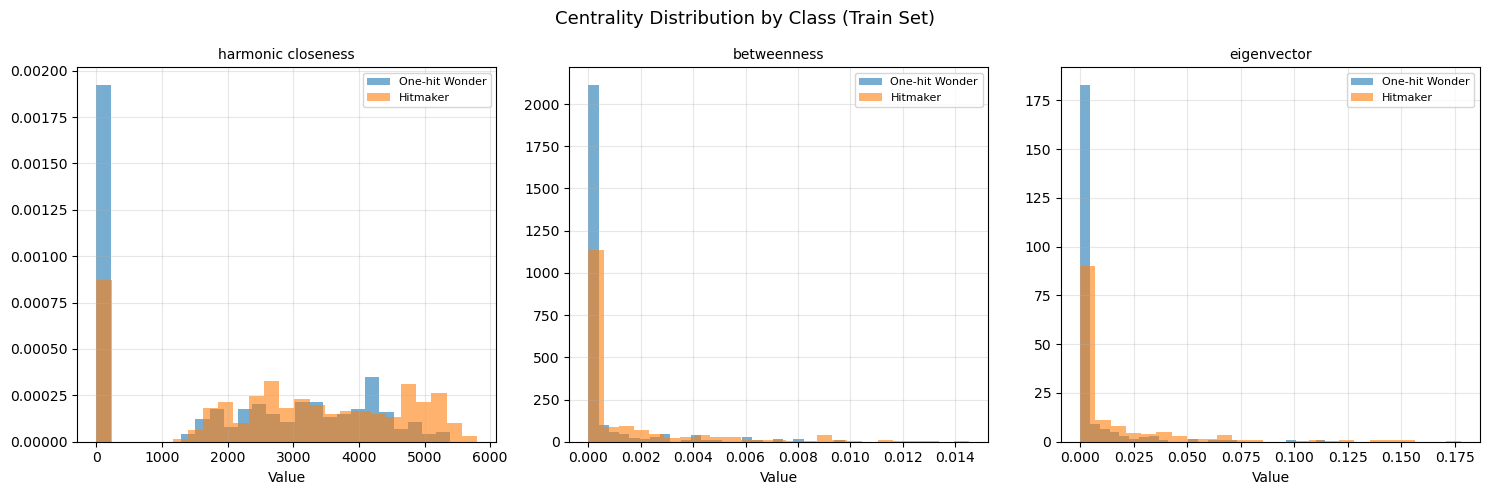

Pearson correlation with top_20_hitmaker (train set):
harmonic_closeness_centrality_top20_rolling5    0.240
betweenness_centrality_top20_rolling5           0.225
eigenvector_centrality_top20_rolling5           0.264
Name: top_20_hitmaker, dtype: float64


In [6]:
# Centrality distributions by class — shows whether network position
# (betweenness, eigenvector, harmonic closeness) differs between hitmakers
# and one-hit wonders. Computed on the training set only; the test set is
# kept completely unseen at this stage.
# Pearson correlations with target provide a quick linear signal check.

cent_cols = [c for c in X.columns if 'centrality' in c]
df_eda    = X_train.copy()
df_eda['top_20_hitmaker'] = y_train.values

fig, axes = plt.subplots(1, len(cent_cols), figsize=(5 * len(cent_cols), 5))
for ax, col in zip(axes, cent_cols):
    for label, grp in df_eda.groupby('top_20_hitmaker'):
        lbl = 'Hitmaker' if label == 1 else 'One-hit Wonder'
        ax.hist(grp[col].dropna(), bins=25, alpha=0.6, label=lbl, density=True)
    short = col.replace('_centrality_top20_rolling5', '').replace('_', ' ')
    ax.set_title(short, fontsize=10)
    ax.set_xlabel('Value'); ax.legend(fontsize=8); ax.grid(True, alpha=0.3)
plt.suptitle('Centrality Distribution by Class (Train Set)', fontsize=13)
plt.tight_layout(); plt.show()

print('Pearson correlation with top_20_hitmaker (train set):')
print(df_eda[cent_cols + ['top_20_hitmaker']].corr()['top_20_hitmaker']
      .drop('top_20_hitmaker').round(3))

## Model setup

In [7]:
# Single entry point for constructing any of the 6 classifiers.
# All models are sklearn-compatible (fit / predict_proba).
# Key design choices:
#   AdaBoost Linear  — SGDClassifier(loss='log_loss') weak learner (linear, scale-sensitive).
#   AdaBoost Tree    — DecisionTreeClassifier weak learner (classic Freund & Schapire 1997).
#   Random Forest    — class_weight='balanced' for the 57/43 imbalance.
#   LightGBM/XGBoost/CatBoost — gradient boosting with regularization tuned by Optuna.

def build_model(name, params):
    if name == 'AdaBoost Linear':
        base = SGDClassifier(
            loss='log_loss',
            alpha=params.get('alpha', 1e-4),
            penalty=params.get('penalty', 'l2'),
            l1_ratio=params.get('l1_ratio', 0.15),
            max_iter=1000, random_state=RANDOM_STATE,
        )
        return AdaBoostClassifier(
            estimator=base,
            n_estimators=params['n_estimators'],
            learning_rate=params['learning_rate'],
            random_state=RANDOM_STATE,
        )
    elif name == 'AdaBoost Tree':
        base = DecisionTreeClassifier(
            max_depth=params.get('max_depth', 1),
            random_state=RANDOM_STATE,
        )
        return AdaBoostClassifier(
            estimator=base,
            n_estimators=params['n_estimators'],
            learning_rate=params['learning_rate'],
            random_state=RANDOM_STATE,
        )
    elif name == 'Random Forest':
        return RandomForestClassifier(
            n_estimators=params['n_estimators'],
            max_depth=params.get('max_depth', None),
            min_samples_leaf=params.get('min_samples_leaf', 1),
            max_features=params.get('max_features', 'sqrt'),
            class_weight='balanced',
            random_state=RANDOM_STATE, n_jobs=-1,
        )
    elif name == 'LightGBM':
        return LGBMClassifier(
            n_estimators=params['n_estimators'],
            learning_rate=params['learning_rate'],
            max_depth=params.get('max_depth', -1),
            num_leaves=params.get('num_leaves', 31),
            reg_alpha=params.get('reg_alpha', 0.0),
            reg_lambda=params.get('reg_lambda', 0.0),
            min_child_samples=params.get('min_child_samples', 20),
            random_state=RANDOM_STATE, verbose=-1, n_jobs=-1,
        )
    elif name == 'XGBoost':
        return XGBClassifier(
            n_estimators=params['n_estimators'],
            learning_rate=params['learning_rate'],
            max_depth=params.get('max_depth', 3),
            min_child_weight=params.get('min_child_weight', 1),
            gamma=params.get('gamma', 0.0),
            subsample=params.get('subsample', 0.8),
            colsample_bytree=params.get('colsample_bytree', 0.8),
            reg_alpha=params.get('reg_alpha', 0.0),
            reg_lambda=params.get('reg_lambda', 1.0),
            random_state=RANDOM_STATE, eval_metric='logloss', verbosity=0,
        )
    elif name == 'CatBoost':
        return CatBoostClassifier(
            iterations=params['n_estimators'],
            learning_rate=params['learning_rate'],
            depth=params.get('depth', 4),
            l2_leaf_reg=params.get('l2_leaf_reg', 3.0),
            random_strength=params.get('random_strength', 1.0),
            border_count=params.get('border_count', 128),
            random_seed=RANDOM_STATE, verbose=0,
        )
    raise ValueError(f'Unknown model: {name}')

In [8]:
# make_optuna_objective: returns a trial->penalized_score function per model.
#   Penalized score = CV AUC - LAM * overfit_gap.
#   try/except handles the rare AdaBoost 'base estimator worse than random' error.
#
# cv_evaluate: 5-fold evaluation returning mean +/- std across folds.
#   CV AUC std captures fold-to-fold variance -- a wide std signals instability.

def make_optuna_objective(name, X, y, lam, skf):
    def objective(trial):
        if name == 'AdaBoost Linear':
            penalty = trial.suggest_categorical('penalty', ['l1', 'l2', 'elasticnet'])
            params = {
                'n_estimators':  trial.suggest_int('n_estimators', 50, 300),
                'learning_rate': trial.suggest_float('learning_rate', 0.01, 2.0, log=True),
                'alpha':         trial.suggest_float('alpha', 1e-5, 1.0, log=True),
                'penalty':       penalty,
                'l1_ratio':      trial.suggest_float('l1_ratio', 0.1, 0.9) if penalty == 'elasticnet' else 0.15,
            }
        elif name == 'AdaBoost Tree':
            params = {
                'n_estimators':  trial.suggest_int('n_estimators', 50, 300),
                'learning_rate': trial.suggest_float('learning_rate', 0.01, 2.0, log=True),
                'max_depth':     trial.suggest_int('max_depth', 1, 4),
            }
        elif name == 'Random Forest':
            params = {
                'n_estimators':     trial.suggest_int('n_estimators', 100, 500),
                'max_depth':        trial.suggest_int('max_depth', 2, 15),
                'min_samples_leaf': trial.suggest_int('min_samples_leaf', 1, 20),
                'max_features':     trial.suggest_categorical('max_features', ['sqrt', 'log2', 0.3, 0.5, 0.7]),
            }
        elif name == 'LightGBM':
            params = {
                'n_estimators':      trial.suggest_int('n_estimators', 50, 500),
                'learning_rate':     trial.suggest_float('learning_rate', 0.005, 0.3, log=True),
                'max_depth':         trial.suggest_int('max_depth', 3, 12),
                'num_leaves':        trial.suggest_int('num_leaves', 8, 128),
                'reg_alpha':         trial.suggest_float('reg_alpha', 1e-4, 10.0, log=True),
                'reg_lambda':        trial.suggest_float('reg_lambda', 1e-4, 10.0, log=True),
                'min_child_samples': trial.suggest_int('min_child_samples', 5, 50),
            }
        elif name == 'XGBoost':
            params = {
                'n_estimators':     trial.suggest_int('n_estimators', 50, 500),
                'learning_rate':    trial.suggest_float('learning_rate', 0.005, 0.3, log=True),
                'max_depth':        trial.suggest_int('max_depth', 2, 8),
                'min_child_weight': trial.suggest_int('min_child_weight', 1, 20),
                'gamma':            trial.suggest_float('gamma', 0.0, 5.0),
                'subsample':        trial.suggest_float('subsample', 0.5, 1.0),
                'colsample_bytree': trial.suggest_float('colsample_bytree', 0.3, 1.0),
                'reg_alpha':        trial.suggest_float('reg_alpha', 1e-4, 10.0, log=True),
                'reg_lambda':       trial.suggest_float('reg_lambda', 1e-4, 10.0, log=True),
            }
        elif name == 'CatBoost':
            params = {
                'n_estimators':    trial.suggest_int('n_estimators', 50, 500),
                'learning_rate':   trial.suggest_float('learning_rate', 0.005, 0.3, log=True),
                'depth':           trial.suggest_int('depth', 2, 8),
                'l2_leaf_reg':     trial.suggest_float('l2_leaf_reg', 0.5, 10.0, log=True),
                'random_strength': trial.suggest_float('random_strength', 0.1, 5.0, log=True),
                'border_count':    trial.suggest_int('border_count', 32, 255),
            }
        fold_val_auc, fold_train_auc = [], []
        for train_idx, val_idx in skf.split(X, y):
            X_tr, X_val = X.iloc[train_idx], X.iloc[val_idx]
            y_tr, y_val = y.iloc[train_idx], y.iloc[val_idx]
            model = build_model(name, params)
            try:
                model.fit(X_tr, y_tr)
                fold_val_auc.append(roc_auc_score(y_val, model.predict_proba(X_val)[:, 1]))
                fold_train_auc.append(roc_auc_score(y_tr, model.predict_proba(X_tr)[:, 1]))
            except Exception:
                fold_val_auc.append(np.nan)
                fold_train_auc.append(np.nan)
        val_auc = np.nanmean(fold_val_auc)
        gap     = np.nanmean(fold_train_auc) - val_auc
        return val_auc - lam * gap
    return objective


def cv_evaluate(name, X, y, params, skf):
    fold_val_auc, fold_train_auc, fold_logloss, fold_brier = [], [], [], []
    for train_idx, val_idx in skf.split(X, y):
        X_tr, X_val = X.iloc[train_idx], X.iloc[val_idx]
        y_tr, y_val = y.iloc[train_idx], y.iloc[val_idx]
        model = build_model(name, params)
        try:
            model.fit(X_tr, y_tr)
            proba    = model.predict_proba(X_val)[:, 1]
            proba_tr = model.predict_proba(X_tr)[:, 1]
            fold_val_auc.append(roc_auc_score(y_val, proba))
            fold_train_auc.append(roc_auc_score(y_tr, proba_tr))
            fold_logloss.append(log_loss(y_val, proba))
            fold_brier.append(brier_score_loss(y_val, proba))
        except Exception:
            fold_val_auc.append(np.nan); fold_train_auc.append(np.nan)
            fold_logloss.append(np.nan); fold_brier.append(np.nan)
    valid_val = [v for v in fold_val_auc if not np.isnan(v)]
    return {
        'CV AUC':      np.nanmean(fold_val_auc),
        'CV AUC Std':  np.std(valid_val) if valid_val else np.nan,
        'Train AUC':   np.nanmean(fold_train_auc),
        'Overfit Gap': np.nanmean(fold_train_auc) - np.nanmean(fold_val_auc),
        'Logloss':     np.nanmean(fold_logloss),
        'BrierScore':  np.nanmean(fold_brier),
    }

## Pipeline

In [9]:
# Imputer fit on training set only -- prevents leakage of test-set statistics.
# StandardScaler applied only for AdaBoost Linear: SGDClassifier gradient updates
# depend on feature magnitude, while tree-based models split on rank order and
# are invariant to monotonic transformations like scaling.
# Both imputer and scaler are stored in PIPE so they can be reapplied to any
# feature subset derived during forward selection.

PIPE = {name: {} for name in MODEL_NAMES}

for name in MODEL_NAMES:
    imputer  = SimpleImputer(strategy='median')
    X_tr_imp = pd.DataFrame(
        imputer.fit_transform(X_train),
        columns=X_train.columns, index=X_train.index,
    )
    X_te_imp = pd.DataFrame(
        imputer.transform(X_test),
        columns=X_test.columns, index=X_test.index,
    )
    if MODEL_NEEDS_SCALER[name]:
        scaler   = StandardScaler()
        X_tr_imp = pd.DataFrame(
            scaler.fit_transform(X_tr_imp),
            columns=X_tr_imp.columns, index=X_tr_imp.index,
        )
        X_te_imp = pd.DataFrame(
            scaler.transform(X_te_imp),
            columns=X_te_imp.columns, index=X_te_imp.index,
        )
        PIPE[name]['scaler'] = scaler
    PIPE[name]['imputer']       = imputer
    PIPE[name]['X_train_clean'] = X_tr_imp
    PIPE[name]['X_test_clean']  = X_te_imp

print('Preprocessing complete.')
for name in MODEL_NAMES:
    print(f'  {name:20s}  train {PIPE[name]["X_train_clean"].shape}'
          f'  NaN={PIPE[name]["X_train_clean"].isna().sum().sum()}'
          f'  scaled={MODEL_NEEDS_SCALER[name]}')

Preprocessing complete.
  AdaBoost Linear       train (607, 26)  NaN=0  scaled=True
  AdaBoost Tree         train (607, 26)  NaN=0  scaled=False
  Random Forest         train (607, 26)  NaN=0  scaled=False
  LightGBM              train (607, 26)  NaN=0  scaled=False
  XGBoost               train (607, 26)  NaN=0  scaled=False
  CatBoost              train (607, 26)  NaN=0  scaled=False


### Step 1 — Full-feature Optuna tuning

In [10]:
# Tune each model on the full 26-feature set before any feature selection.
# We tune first so that permutation importance in Step 2 reflects a
# well-regularized model rather than arbitrary default hyperparameters.
# Objective: AUC - LAM * overfit_gap (LAM=0.3).
# Expected runtime: ~20-40 min total across all 6 models.

for name in MODEL_NAMES:
    print(f'\n{"="*60}')
    print(f'  Optuna (full features): {name}  [{N_TRIALS_FULL} trials]')
    print(f'{"="*60}')
    X_tr  = PIPE[name]['X_train_clean']
    study = optuna.create_study(direction='maximize', sampler=TPESampler(seed=RANDOM_STATE))
    study.optimize(
        make_optuna_objective(name, X_tr, y_train, LAM, skf),
        n_trials=N_TRIALS_FULL, show_progress_bar=True,
    )
    res = cv_evaluate(name, X_tr, y_train, study.best_params, skf)
    PIPE[name]['study_full']  = study
    PIPE[name]['params_full'] = study.best_params
    PIPE[name]['cv_full']     = res
    print(f'  CV AUC:      {res["CV AUC"]:.4f} +/- {res["CV AUC Std"]:.4f}')
    print(f'  Train AUC:   {res["Train AUC"]:.4f}')
    print(f'  Overfit Gap: {res["Overfit Gap"]:.4f}')
    print(f'  Best params: {study.best_params}')

print('\n\n-- Full-Feature Optuna Summary --')
rows = []
for name in MODEL_NAMES:
    r = PIPE[name]['cv_full']
    rows.append({
        'Model':       name,
        'CV AUC':      f'{r["CV AUC"]:.4f} +/- {r["CV AUC Std"]:.4f}',
        'Train AUC':   round(r['Train AUC'], 4),
        'Overfit Gap': round(r['Overfit Gap'], 4),
        'Logloss':     round(r['Logloss'], 4),
        'BrierScore':  round(r['BrierScore'], 4),
    })
print(pd.DataFrame(rows).set_index('Model').to_string())


  Optuna (full features): AdaBoost Linear  [30 trials]


  0%|          | 0/30 [00:00<?, ?it/s]

  CV AUC:      0.7302 +/- 0.0252
  Train AUC:   0.7438
  Overfit Gap: 0.0136
  Best params: {'penalty': 'elasticnet', 'n_estimators': 126, 'learning_rate': 0.021429987722827143, 'alpha': 0.00028020247048981487, 'l1_ratio': 0.28347731781562313}

  Optuna (full features): AdaBoost Tree  [30 trials]


  0%|          | 0/30 [00:00<?, ?it/s]

  CV AUC:      0.7467 +/- 0.0248
  Train AUC:   0.7967
  Overfit Gap: 0.0500
  Best params: {'n_estimators': 211, 'learning_rate': 0.015380118677333066, 'max_depth': 2}

  Optuna (full features): Random Forest  [30 trials]


...

  CV AUC:      0.7565 +/- 0.0393
  Train AUC:   0.8284
  Overfit Gap: 0.0720
  Best params: {'n_estimators': 337, 'learning_rate': 0.005754000344194488, 'max_depth': 12, 'num_leaves': 41, 'reg_alpha': 0.00011054186971211229, 'reg_lambda': 5.8629726503511685, 'min_child_samples': 38}

  Optuna (full features): XGBoost  [30 trials]


  0%|          | 0/30 [00:00<?, ?it/s]

  CV AUC:      0.7529 +/- 0.0293
  Train AUC:   0.7835
  Overfit Gap: 0.0306
  Best params: {'n_estimators': 441, 'learning_rate': 0.012069403958948477, 'max_depth': 7, 'min_child_weight': 12, 'gamma': 4.497502466410312, 'subsample': 0.619720671481651, 'colsample_bytree': 0.3567688249674947, 'reg_alpha': 1.412544348193982, 'reg_lambda': 0.10027803698862342}

  Optuna (full features): CatBoost  [30 trials]


  0%|          | 0/30 [00:00<?, ?it/s]

  CV AUC:      0.7534 +/- 0.0268
  Train AUC:   0.7901
  Overfit Gap: 0.0367
  Best params: {'n_estimators': 289, 'learning_rate': 0.00689713688485784, 'depth': 2, 'l2_leaf_reg': 1.6775656280511797, 'random_strength': 1.793639136205124, 'border_count': 217}


-- Full-Feature Optuna Summary --
                            CV AUC  Train AUC  Overfit Gap  Logloss  BrierScore
Model                                                                          
AdaBoost Linear  0.7302 +/- 0.0252     0.7438       0.0136   0.6780      0.2329
AdaBoost Tree    0.7467 +/- 0.0248     0.7967       0.0500   0.5925      0.2041
Random Forest    0.7508 +/- 0.0300     0.7853       0.0345   0.6021      0.2070
LightGBM         0.7565 +/- 0.0393     0.8284       0.0720   0.5814      0.1990
XGBoost          0.7529 +/- 0.0293     0.7835       0.0306   0.5890      0.2019
CatBoost         0.7534 +/- 0.0268     0.7901       0.0367   0.5965      0.2045


### Step 2 — Cross-validated permutation importance


AdaBoost Linear
                                     Feature  Importance      Std
       eigenvector_centrality_top20_rolling5    0.042707 0.018191
                        artist_genre_unknown    0.040303 0.017662
#_of_charting_songs_through_first_top_20_hit    0.039531 0.011082
                            artist_genre_Pop    0.018130 0.004915
                    artist_genre_Hip Hop/Rap    0.014474 0.007078
                  artist_genre_R&B/Soul/Funk    0.007778 0.006930
 top_20_hit_song_#_wks_on_chart_any_position    0.006395 0.004131
       betweenness_centrality_top20_rolling5    0.004139 0.004244
                          #_of_genres_artist    0.000208 0.002488
                           artist_genre_Folk    0.000011 0.000022
       artist_genre_Experimental/Avant-Garde    0.000000 0.000000
               artist_genre_Electronic/Dance    0.000000 0.000000
           artist_genre_Easy Listening/Vocal    0.000000 0.000000
              artist_genre_Country/Americana    0.000000 0.

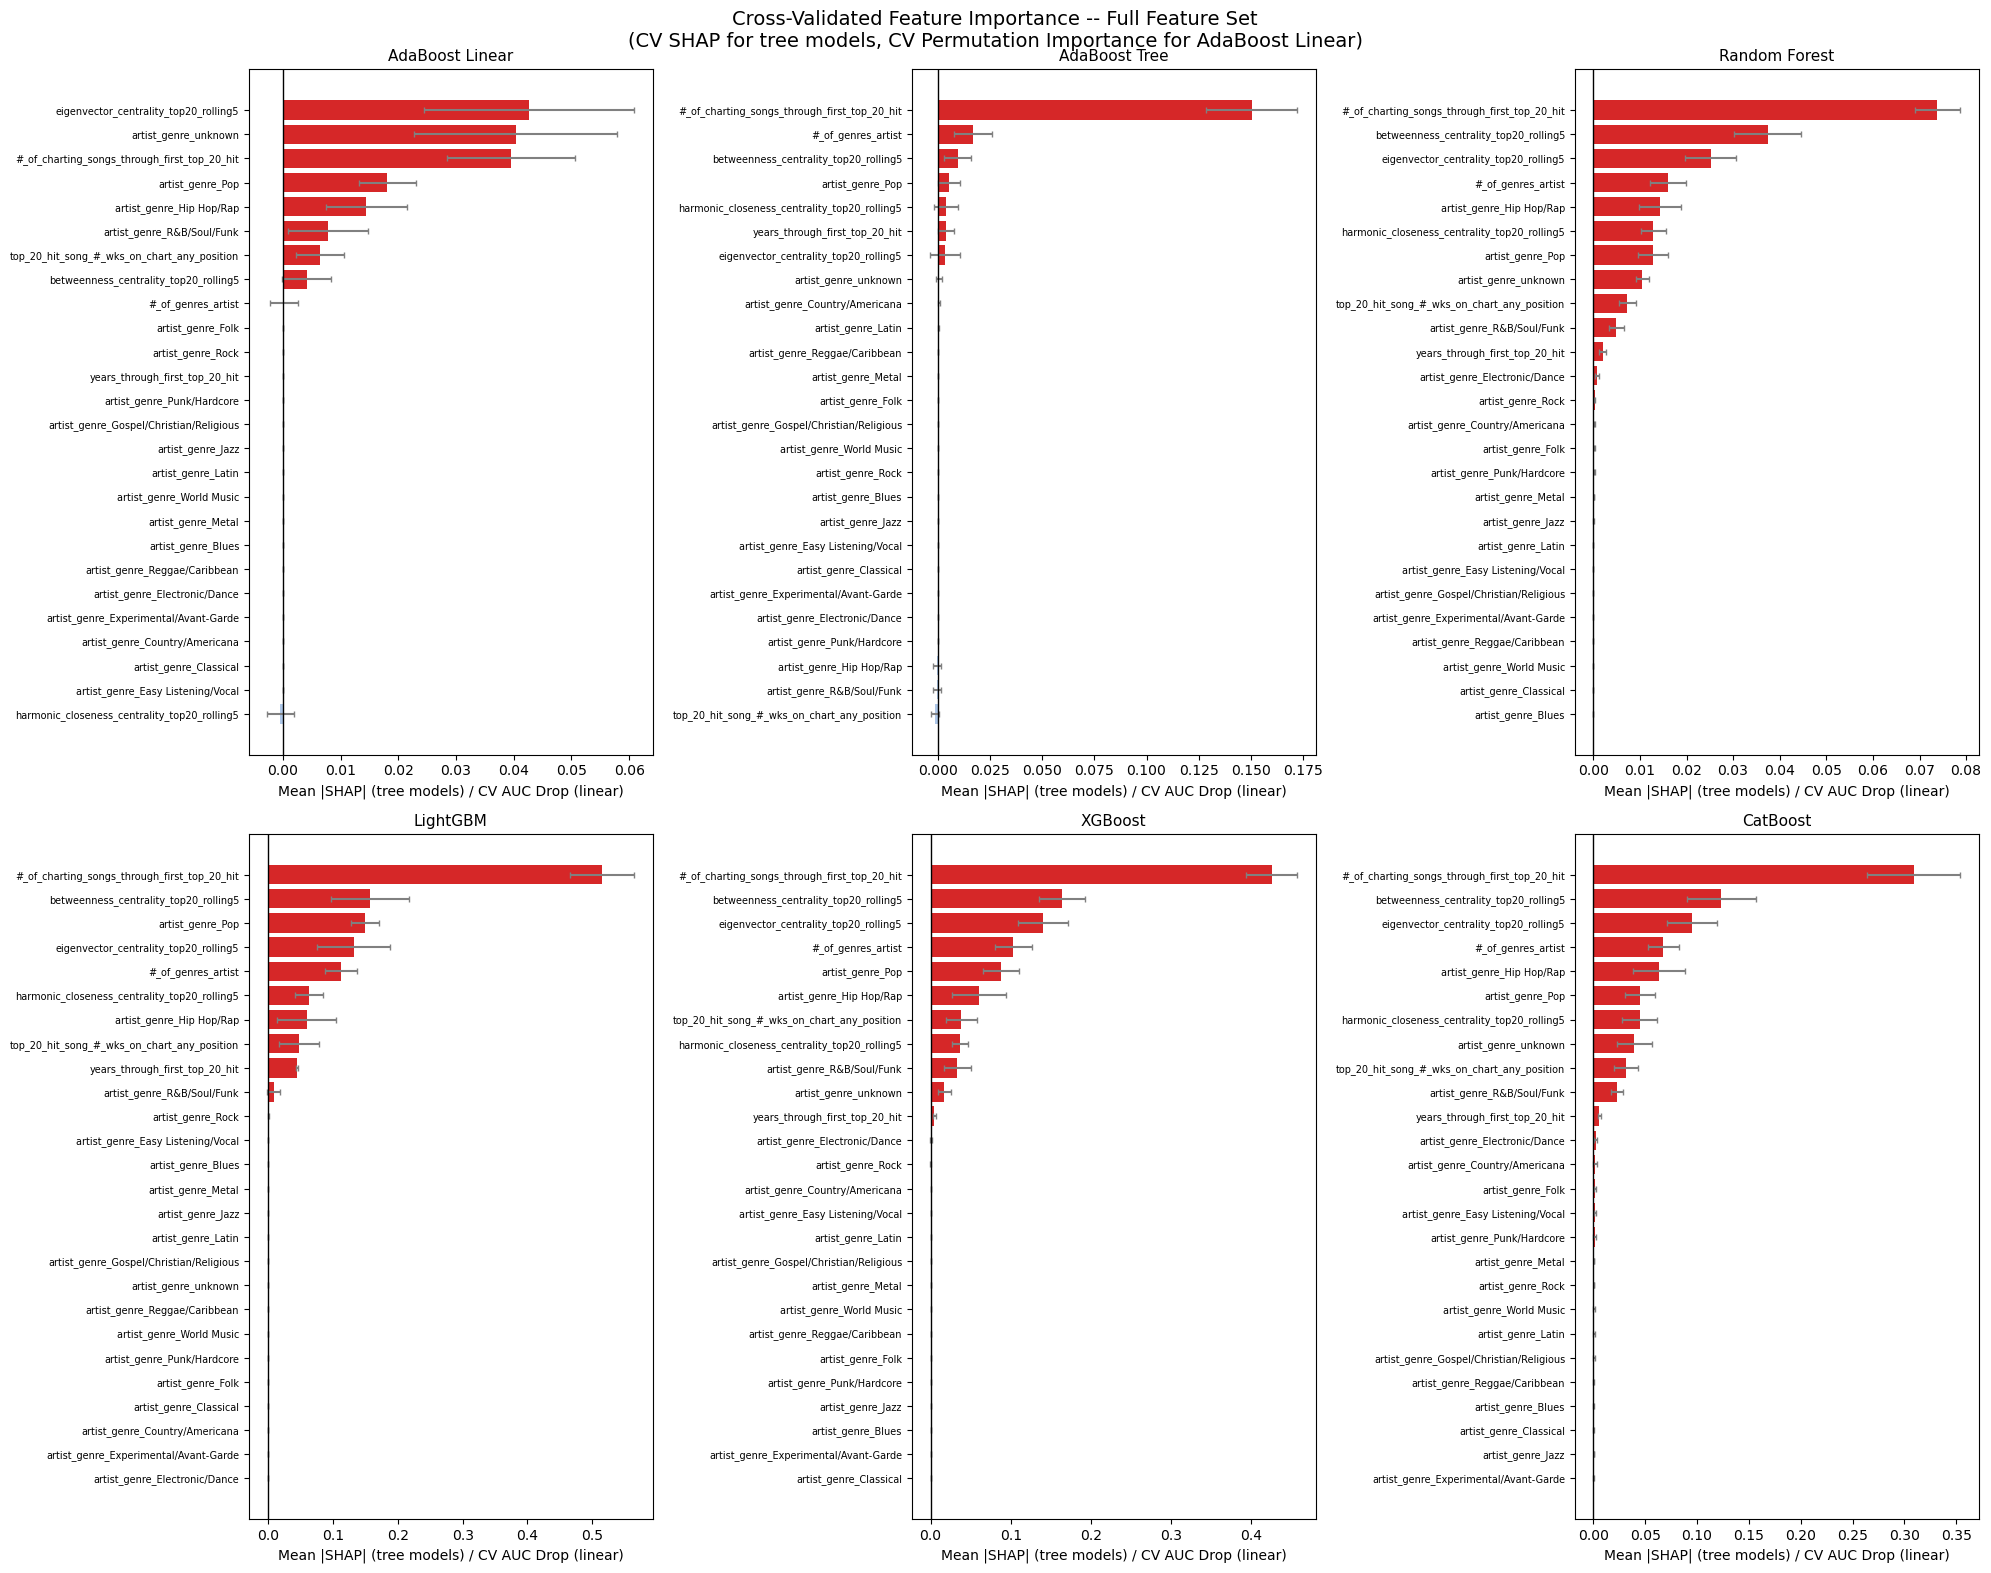

In [11]:
# Step 2: Cross-validated feature importance — unified for Steps 2 and 3.
#
# Standard permutation importance computed on training data is optimistic:
# the model has memorized some of that data, inflating scores for noise features.
# The same problem affects SHAP computed on training data: a complex model can
# assign non-zero SHAP to rare genres it memorized (e.g. 2-3 artists), making
# them appear informative even though the signal doesn't generalize.
#
# Solution: compute importance on the *validation* fold of each CV split.
# The model never saw that fold, so scores reflect genuine out-of-sample
# feature contributions. Noise patterns memorized on the training fold will
# produce near-zero importance on the validation fold.
#
# For tree-based models we attempt SHAP TreeExplainer (exact, fast) on the
# validation fold. AdaBoost Tree stumps are not supported by TreeExplainer
# so we fall back to CV permutation importance per fold automatically.
# For AdaBoost Linear (SGDClassifier), perm importance is used throughout.
#
# Output stored in PIPE[name]['perm_full'] for all models (mean/std across folds).
# Step 3 consumes this output directly — no separate SHAP computation needed.

TREE_MODEL_NAMES_2 = {'AdaBoost Tree', 'Random Forest', 'LightGBM', 'XGBoost', 'CatBoost'}

for name in MODEL_NAMES:
    print(f'\n{name}')
    X_tr   = PIPE[name]['X_train_clean']
    params = PIPE[name]['params_full']
    fold_importances = []

    for train_idx, val_idx in skf.split(X_tr, y_train):
        X_f, X_v = X_tr.iloc[train_idx], X_tr.iloc[val_idx]
        y_f, y_v = y_train.iloc[train_idx], y_train.iloc[val_idx]
        model = build_model(name, params)
        try:
            model.fit(X_f, y_f)
            if name in TREE_MODEL_NAMES_2:
                try:
                    # CV SHAP: model trained on fold, SHAP computed on held-out validation
                    explainer = shap.TreeExplainer(model)
                    sv = explainer.shap_values(X_v)
                    if isinstance(sv, list):
                        sv = sv[1]
                    elif sv.ndim == 3:
                        sv = sv[:, :, 1]
                    fold_importances.append(np.abs(sv).mean(axis=0))
                except Exception:
                    # SHAP not supported for this model (e.g. AdaBoost Tree stumps)
                    # fall back to CV permutation importance on the validation fold
                    perm = permutation_importance(
                        model, X_v, y_v,
                        n_repeats=5, random_state=RANDOM_STATE, scoring='roc_auc',
                    )
                    fold_importances.append(perm.importances_mean)
            else:
                # CV permutation importance for AdaBoost Linear
                perm = permutation_importance(
                    model, X_v, y_v,
                    n_repeats=5, random_state=RANDOM_STATE, scoring='roc_auc',
                )
                fold_importances.append(perm.importances_mean)
        except Exception as e:
            print(f'  fold error ({e})')

    mean_imp = np.mean(fold_importances, axis=0)
    std_imp  = np.std(fold_importances, axis=0)
    perm_df  = pd.DataFrame({
        'Feature':    X_tr.columns,
        'Importance': mean_imp,
        'Std':        std_imp,
    }).sort_values('Importance', ascending=False).reset_index(drop=True)
    PIPE[name]['perm_full'] = perm_df
    print(perm_df.to_string(index=False))

fig, axes = plt.subplots(2, 3, figsize=(20, 16))
for ax, name in zip(axes.flat, MODEL_NAMES):
    df_p   = PIPE[name]['perm_full'].sort_values('Importance', ascending=True)
    colors = ['#d62728' if v > 0 else '#aec7e8' for v in df_p['Importance']]
    ax.barh(df_p['Feature'], df_p['Importance'], xerr=df_p['Std'],
            color=colors, error_kw={'ecolor': 'gray', 'capsize': 2})
    ax.axvline(0, color='black', linewidth=1)
    ax.set_title(name, fontsize=11)
    ax.set_xlabel('Mean |SHAP| (tree models) / CV AUC Drop (linear)')
    ax.tick_params(axis='y', labelsize=7)
plt.suptitle('Cross-Validated Feature Importance -- Full Feature Set\n'
             '(CV SHAP for tree models, CV Permutation Importance for AdaBoost Linear)',
             fontsize=14)
plt.tight_layout(); plt.show()

### Step 3 — Dynamic genre consolidation

In [12]:
# Step 3: Genre consolidation using CV importance from Step 2.
#
# Tree models (RF, LightGBM, XGBoost, CatBoost) use CV SHAP importance.
# CV SHAP is conservative on held-out data but still finds tiny non-zero values
# for nearly every genre in complex models (CatBoost, RF) — using > 0 would
# keep 19+ genres for CatBoost, defeating consolidation entirely.
# Fix: SHAP-based models use importance > mean(genre importances), which keeps
# only above-average signal genres. Perm-based models (AdaBoost Linear/Tree)
# use importance > 0 since permutation importance is already sparse.
#
# Consolidation is per-model and applied to both train and test using only
# training-set statistics (no leakage). Low-signal genres are merged into
# artist_genre_other — preserving the signal that "artist has an obscure genre"
# without keeping many near-zero dummy columns.

# Tree models that use CV SHAP in Step 2
SHAP_MODELS = {'Random Forest', 'LightGBM', 'XGBoost', 'CatBoost'}

def consolidate_genres(X_tr, X_te, high_signal, all_genre_cols):
    """Drop low-signal genre dummies and fold them into artist_genre_other."""
    low_signal = [c for c in all_genre_cols if c not in high_signal]
    X_tr_c = X_tr.drop(columns=low_signal).copy()
    X_te_c = X_te.drop(columns=low_signal).copy()
    if low_signal:
        X_tr_c['artist_genre_other'] = (X_tr[low_signal].sum(axis=1) > 0).astype(int)
        X_te_c['artist_genre_other'] = (X_te[low_signal].sum(axis=1) > 0).astype(int)
    return X_tr_c, X_te_c, low_signal

for name in MODEL_NAMES:
    X_tr    = PIPE[name]['X_train_clean']
    X_te    = PIPE[name]['X_test_clean']
    perm_df = PIPE[name]['perm_full']

    all_genre_cols = [c for c in X_tr.columns if c.startswith('artist_genre_')]
    genre_imp      = perm_df.set_index('Feature')['Importance']

    if name in SHAP_MODELS:
        # SHAP importance: keep genres above mean — prevents complex models from
        # retaining every genre with a tiny non-zero SHAP value
        genre_vals  = genre_imp[[c for c in all_genre_cols if c in genre_imp.index]]
        genre_mean  = genre_vals.mean()
        high_signal = [c for c in all_genre_cols if genre_imp.get(c, 0) > genre_mean]
    else:
        # Perm importance: > 0 is already conservative enough
        high_signal = [c for c in all_genre_cols if genre_imp.get(c, 0) > 0]

    X_tr_cons, X_te_cons, low_signal = consolidate_genres(X_tr, X_te, high_signal, all_genre_cols)

    PIPE[name]['X_train_cons']       = X_tr_cons
    PIPE[name]['X_test_cons']        = X_te_cons
    PIPE[name]['high_signal_genres'] = high_signal
    PIPE[name]['low_signal_genres']  = low_signal

    print(f'{name}:')
    print(f'  kept {len(high_signal)} genres: {[c.replace("artist_genre_", "") for c in high_signal]}')
    print(f'  merged {len(low_signal)} -> artist_genre_other  |  total features: {X_tr_cons.shape[1]}')

AdaBoost Linear:
  kept 5 genres: ['Folk', 'Hip Hop/Rap', 'Pop', 'R&B/Soul/Funk', 'unknown']
  merged 14 -> artist_genre_other  |  total features: 13
AdaBoost Tree:
  kept 4 genres: ['Country/Americana', 'Latin', 'Pop', 'unknown']
  merged 15 -> artist_genre_other  |  total features: 12
Random Forest:
  kept 4 genres: ['Hip Hop/Rap', 'Pop', 'R&B/Soul/Funk', 'unknown']
  merged 15 -> artist_genre_other  |  total features: 12
LightGBM:
  kept 2 genres: ['Hip Hop/Rap', 'Pop']
  merged 17 -> artist_genre_other  |  total features: 10
XGBoost:
  kept 4 genres: ['Hip Hop/Rap', 'Pop', 'R&B/Soul/Funk', 'unknown']
  merged 15 -> artist_genre_other  |  total features: 12
CatBoost:
  kept 4 genres: ['Hip Hop/Rap', 'Pop', 'R&B/Soul/Funk', 'unknown']
  merged 15 -> artist_genre_other  |  total features: 12


### Step 4 — Forward selection


────────────────────────────────────────────────────────────
Forward selection: AdaBoost Linear
  n= 3 +[#_of_charting_songs_through_first_top_20]  AUC=0.7140  Gap=-0.0009
  n= 4 +[artist_genre_Pop                        ]  AUC=0.7155  Gap=0.0095
  n= 5 +[artist_genre_Hip Hop/Rap                ]  AUC=0.7273  Gap=0.0026
  n= 6 +[artist_genre_R&B/Soul/Funk              ]  AUC=0.7278  Gap=0.0031
  n= 7 +[top_20_hit_song_#_wks_on_chart_any_posit]  AUC=0.7296  Gap=0.0082
  n= 8 +[betweenness_centrality_top20_rolling5   ]  AUC=0.7299  Gap=0.0145
  n= 9 +[#_of_genres_artist                      ]  AUC=0.7290  Gap=0.0151
  n=10 +[artist_genre_Folk                       ]  AUC=0.7287  Gap=0.0153
  n=11 +[years_through_first_top_20_hit          ]  AUC=0.7308  Gap=0.0132
  n=12 +[harmonic_closeness_centrality_top20_roll]  AUC=0.7305  Gap=0.0125
  n=13 +[artist_genre_other                      ]  AUC=0.7288  Gap=0.0143

────────────────────────────────────────────────────────────
Forward selecti

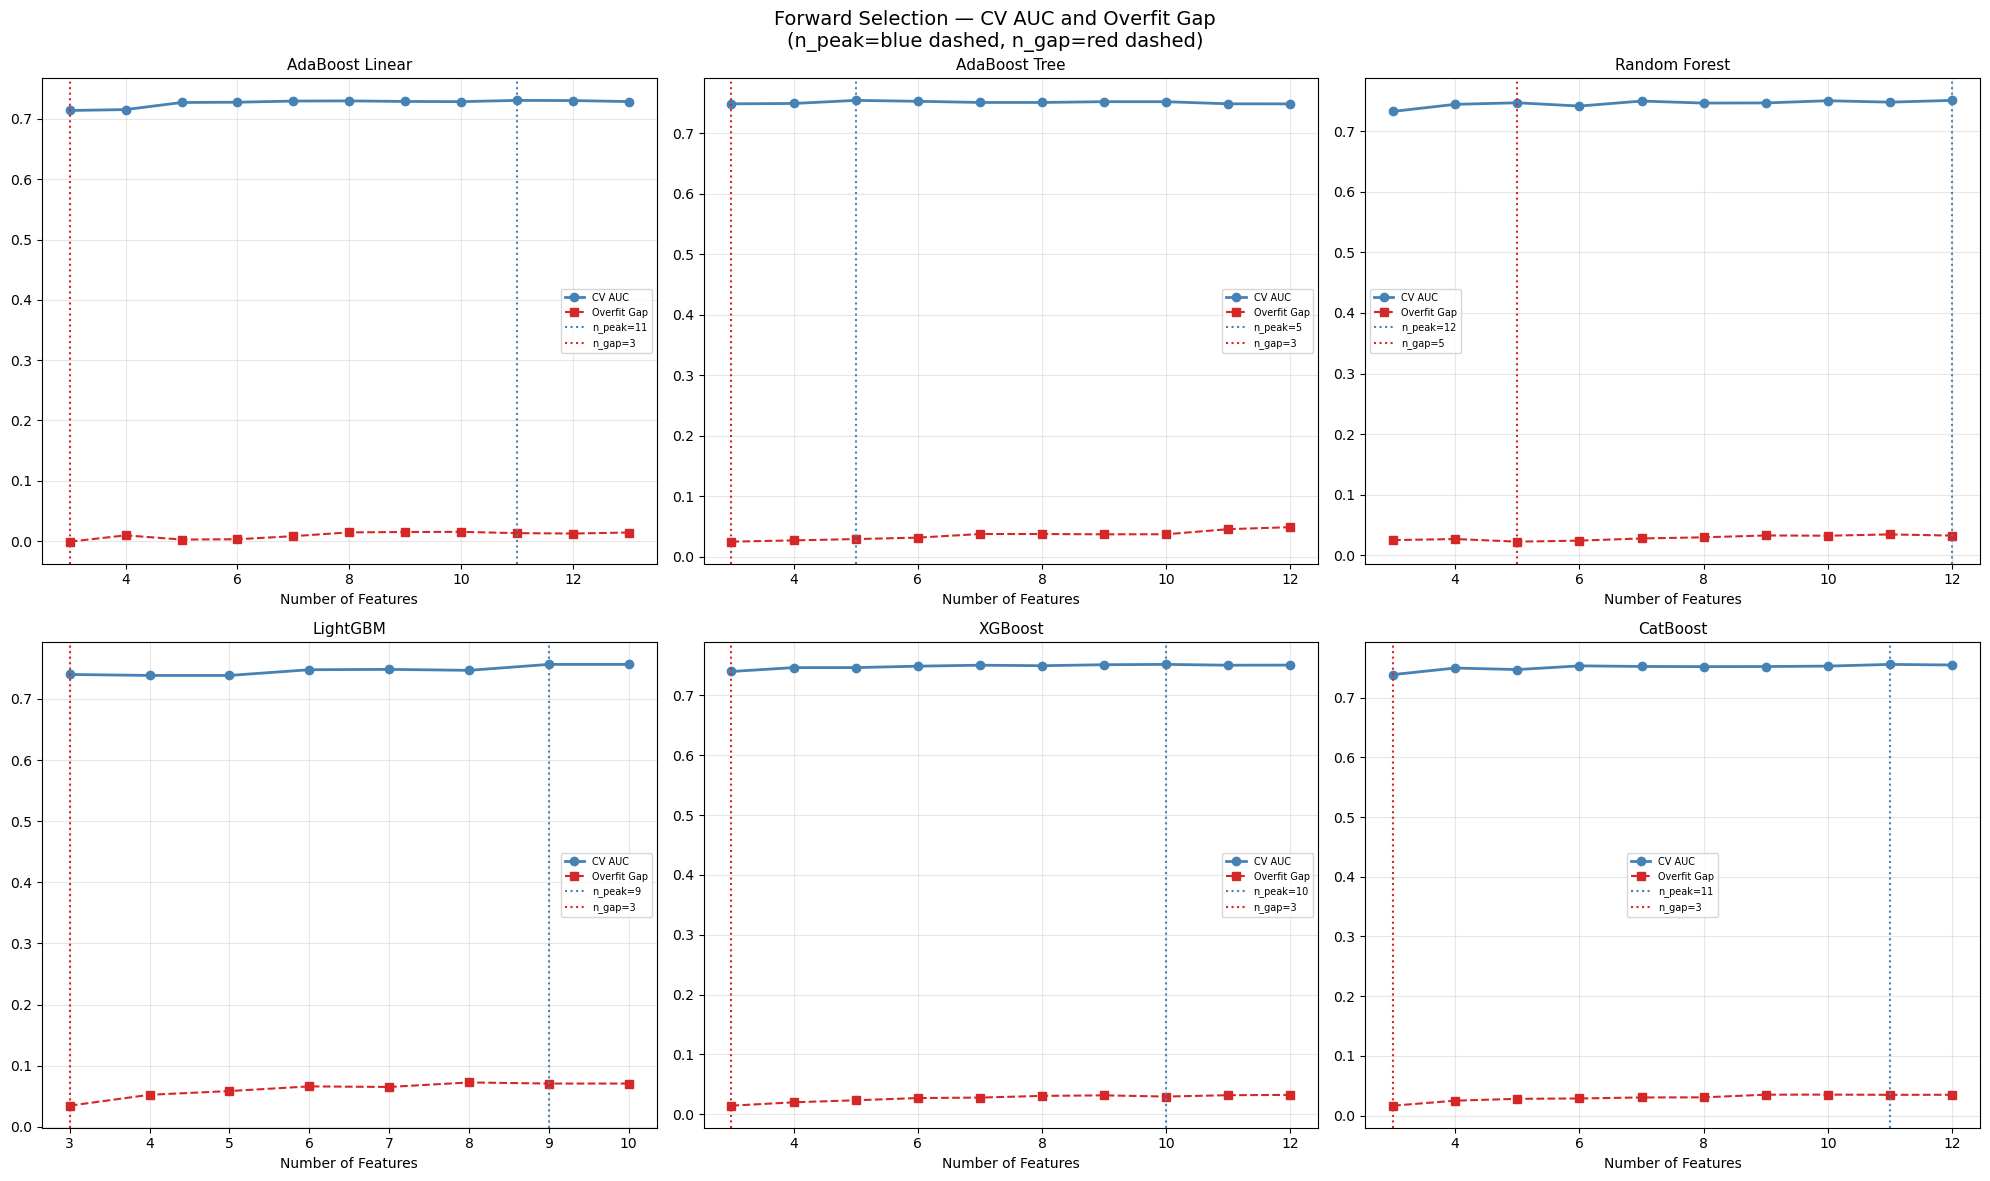

In [13]:
# Step 4: Forward selection on the genre-consolidated feature set.
#
# Following ml_sandbox_18_catboost, centrality features are included in the
# feature pool alongside genre and behavioral features — they are NOT gated
# separately before forward selection. The greedy selection uses Step 2 CV
# importance ordering (no recomputation) and naturally keeps or discards
# centrality features based on their marginal contribution.
#
# We track CV AUC and overfit gap at each n. Two candidate n values are
# passed to Step 5 for Optuna re-tuning:
#   n_peak: maximises CV AUC on the forward selection curve
#   n_gap:  minimises overfit gap (most stable point on the gap curve)

for name in MODEL_NAMES:
    print(f'\n{"─"*60}\nForward selection: {name}')
    X_tr   = PIPE[name]['X_train_cons']
    X_te   = PIPE[name]['X_test_cons']
    params = PIPE[name]['params_full']

    # Feature ordering from Step 2 CV importance, filtered to consolidated pool
    perm_full_order = PIPE[name]['perm_full'].set_index('Feature')['Importance']
    feature_order   = [
        f for f in perm_full_order.sort_values(ascending=False).index
        if f in X_tr.columns
    ]
    # artist_genre_other is created in Step 3 (consolidation) so it has no
    # Step 2 importance score and would be silently excluded from feature_order.
    # Append it at the end so forward selection can evaluate it last.
    other_col = 'artist_genre_other'
    if other_col in X_tr.columns and other_col not in feature_order:
        feature_order.append(other_col)

    PIPE[name]['feature_order'] = feature_order

    sel_results = []
    start_n = min(3, len(feature_order))
    for n_feats in range(start_n, len(feature_order) + 1):
        feats = feature_order[:n_feats]
        X_sub = X_tr[feats]
        fold_val, fold_tr, fold_ll, fold_bs = [], [], [], []
        for train_idx, val_idx in skf.split(X_sub, y_train):
            X_f, X_v = X_sub.iloc[train_idx], X_sub.iloc[val_idx]
            y_f, y_v = y_train.iloc[train_idx], y_train.iloc[val_idx]
            model = build_model(name, params)
            try:
                model.fit(X_f, y_f)
                p_v = model.predict_proba(X_v)[:, 1]
                p_t = model.predict_proba(X_f)[:, 1]
                fold_val.append(roc_auc_score(y_v, p_v))
                fold_tr.append(roc_auc_score(y_f, p_t))
                fold_ll.append(log_loss(y_v, p_v))
                fold_bs.append(brier_score_loss(y_v, p_v))
            except Exception:
                fold_val.append(np.nan); fold_tr.append(np.nan)
                fold_ll.append(np.nan);  fold_bs.append(np.nan)
        val_auc = np.nanmean(fold_val); tr_auc = np.nanmean(fold_tr)
        sel_results.append({
            'n_features':  n_feats,
            'CV AUC':      val_auc,
            'Train AUC':   tr_auc,
            'Overfit Gap': tr_auc - val_auc,
            'Logloss':     np.nanmean(fold_ll),
            'BrierScore':  np.nanmean(fold_bs),
        })
        print(f'  n={n_feats:2d} +[{feature_order[n_feats-1][:40]:40s}]  '
              f'AUC={val_auc:.4f}  Gap={tr_auc - val_auc:.4f}')

    df_sel = pd.DataFrame(sel_results).set_index('n_features')
    PIPE[name]['forward_sel'] = df_sel

fig, axes = plt.subplots(2, 3, figsize=(20, 12))
for ax, name in zip(axes.flat, MODEL_NAMES):
    df_s   = PIPE[name]['forward_sel']
    n_peak = df_s['CV AUC'].idxmax()
    n_gap  = df_s['Overfit Gap'].idxmin()
    ax.plot(df_s.index, df_s['CV AUC'],      'o-', color='steelblue', lw=2, label='CV AUC')
    ax.plot(df_s.index, df_s['Overfit Gap'], 's--', color='#d62728',  lw=1.5, label='Overfit Gap')
    ax.axvline(n_peak, color='steelblue', linestyle=':', lw=1.5, label=f'n_peak={n_peak}')
    ax.axvline(n_gap,  color='#d62728',   linestyle=':', lw=1.5, label=f'n_gap={n_gap}')
    ax.set_title(name, fontsize=11); ax.set_xlabel('Number of Features')
    ax.legend(fontsize=7); ax.grid(True, alpha=0.3)
plt.suptitle('Forward Selection — CV AUC and Overfit Gap\n(n_peak=blue dashed, n_gap=red dashed)', fontsize=14)
plt.tight_layout(); plt.show()

### Step 5 — Optuna re-tune on candidates + winner selection

In [75]:
# Step 5: Re-tune Optuna on candidate n values and select the winner.
#
# Hyperparameters tuned on 26 features may not be optimal for a trimmed subset.
# Following ml_sandbox_18_catboost, we evaluate two candidates per model:
#   n_peak: n with the highest CV AUC on the forward selection curve
#   n_gap:  n with the lowest overfit gap (most parsimonious stable point)
# If n_peak == n_gap, only one Optuna run is needed.
#
# Winner selection: penalized score (CV AUC - LAM * gap) after re-tuning.
# A model that achieves similar AUC with a smaller gap is preferred.
#
# MIN_N: minimum feature count for the winner. The penalized criterion can
# select pathologically sparse models (e.g. LightGBM n=3) when n_gap has
# a low gap but similar AUC to n_peak — the AUC difference is too small for
# any gap-based protection to fire. A floor on n is the right remedy.
# AUC_PROTECTION (override if n_peak AUC > n_gap AUC by a threshold) was
# removed because it never fired in practice: the AUC gap was always <0.01.
MIN_N = 5

for name in MODEL_NAMES:
    print(f'\n{"="*60}\nRe-tune: {name}')
    df_sel    = PIPE[name]['forward_sel']
    feat_ord  = PIPE[name]['feature_order']
    X_tr_cons = PIPE[name]['X_train_cons']
    X_te_cons = PIPE[name]['X_test_cons']

    n_peak = int(df_sel['CV AUC'].idxmax())
    n_gap  = int(df_sel['Overfit Gap'].idxmin())
    candidate_ns = sorted(set([n_peak, n_gap]))
    print(f'  n_peak={n_peak}, n_gap={n_gap}, candidates: {candidate_ns}')

    best_params_by_n = {}
    cv_results_by_n  = {}
    X_train_by_n     = {n: X_tr_cons[feat_ord[:n]] for n in candidate_ns}
    X_test_by_n      = {n: X_te_cons[feat_ord[:n]] for n in candidate_ns}

    for n in candidate_ns:
        print(f'\n  -- n={n}: {feat_ord[:n]}')
        study = optuna.create_study(direction='maximize', sampler=TPESampler(seed=RANDOM_STATE))
        study.optimize(
            make_optuna_objective(name, X_train_by_n[n], y_train, LAM, skf),
            n_trials=N_TRIALS_RETUNE, show_progress_bar=True,
        )
        best_params_by_n[n] = study.best_params
        cv_results_by_n[n]  = cv_evaluate(name, X_train_by_n[n], y_train, study.best_params, skf)
        res = cv_results_by_n[n]
        print(f'  CV AUC={res["CV AUC"]:.4f} +/- {res["CV AUC Std"]:.4f}  '
              f'Gap={res["Overfit Gap"]:.4f}  Penalized={res["CV AUC"] - LAM * res["Overfit Gap"]:.4f}')

    # Winner: highest penalized score (CV AUC - LAM * gap) after re-tuning.
    winner_n = max(candidate_ns,
                   key=lambda n: cv_results_by_n[n]['CV AUC'] - LAM * cv_results_by_n[n]['Overfit Gap'])

    # MIN_N guard: override if the penalized winner is below the minimum feature count.
    min_n_overrode = False
    if winner_n < MIN_N:
        eligible = [n for n in candidate_ns if n >= MIN_N]
        if eligible:
            override_n = min(eligible)
            print(f'  MIN_N override: winner n={winner_n} < {MIN_N} → override to n={override_n}')
            winner_n = override_n
            min_n_overrode = True

    PIPE[name]['best_params_by_n'] = best_params_by_n
    PIPE[name]['cv_results_by_n']  = cv_results_by_n
    PIPE[name]['X_train_by_n']     = X_train_by_n
    PIPE[name]['X_test_by_n']      = X_test_by_n
    PIPE[name]['n_optimal']        = winner_n
    PIPE[name]['params_final']     = best_params_by_n[winner_n]
    PIPE[name]['X_train_final']    = X_train_by_n[winner_n]
    PIPE[name]['X_test_final']     = X_test_by_n[winner_n]
    PIPE[name]['cv_result_final']  = cv_results_by_n[winner_n]

    if n_peak == n_gap:
        decision = 'n_peak=n_gap'
    elif min_n_overrode:
        decision = 'MIN_N override'
    elif winner_n == n_gap:
        decision = 'n_gap wins'
    else:
        decision = 'n_peak wins'
    PIPE[name]['step5_decision'] = decision
    print(f'\n  → Winner: n={winner_n}  ({decision})'
          f'  CV AUC={cv_results_by_n[winner_n]["CV AUC"]:.4f}'
          f'  Gap={cv_results_by_n[winner_n]["Overfit Gap"]:.4f}')

# Summary table
print(f'\n{"─"*80}')
print(f'{"Model":<22}  {"n_peak":>6}  {"n_gap":>5}  {"Winner":>6}  '
      f'{"CV AUC":>8}  {"Gap":>6}  Decision')
print('-' * 80)
for name in MODEL_NAMES:
    df_sel = PIPE[name]['forward_sel']
    n_peak = int(df_sel['CV AUC'].idxmax())
    n_gap  = int(df_sel['Overfit Gap'].idxmin())
    n_win  = PIPE[name]['n_optimal']
    res    = PIPE[name]['cv_result_final']
    print(f'{name:<22}  {n_peak:>6}  {n_gap:>5}  {n_win:>6}  '
          f'{res["CV AUC"]:.4f}  {res["Overfit Gap"]:.4f}  {PIPE[name]["step5_decision"]}')


Re-tune: AdaBoost Linear
  n_peak=11, n_gap=3, candidates: [3, 11]

  -- n=3: ['eigenvector_centrality_top20_rolling5', 'artist_genre_unknown', '#_of_charting_songs_through_first_top_20_hit']


  0%|          | 0/30 [00:00<?, ?it/s]

  CV AUC=0.7270 +/- 0.0273  Gap=-0.0015  Penalized=0.7275

  -- n=11: ['eigenvector_centrality_top20_rolling5', 'artist_genre_unknown', '#_of_charting_songs_through_first_top_20_hit', 'artist_genre_Pop', 'artist_genre_Hip Hop/Rap', 'artist_genre_R&B/Soul/Funk', 'top_20_hit_song_#_wks_on_chart_any_position', 'betweenness_centrality_top20_rolling5', '#_of_genres_artist', 'artist_genre_Folk', 'years_through_first_top_20_hit']


  0%|          | 0/30 [00:00<?, ?it/s]

  CV AUC=0.7411 +/- 0.0201  Gap=0.0205  Penalized=0.7350

  → Winner: n=11  (n_peak wins)  CV AUC=0.7411  Gap=0.0205

Re-tune: AdaBoost Tree
  n_peak=5, n_gap=3, candidates: [3, 5]

  -- n=3: ['#_of_charting_songs_through_first_top_20_hit', '#_of_genres_artist', 'betweenness_centrality_top20_rolling5']


...

  CV AUC=0.7520 +/- 0.0459  Gap=0.0267  Penalized=0.7440

  → Winner: n=10  (n_peak wins)  CV AUC=0.7520  Gap=0.0267

Re-tune: CatBoost
  n_peak=11, n_gap=3, candidates: [3, 11]

  -- n=3: ['#_of_charting_songs_through_first_top_20_hit', 'betweenness_centrality_top20_rolling5', 'eigenvector_centrality_top20_rolling5']


  0%|          | 0/30 [00:00<?, ?it/s]

  CV AUC=0.7408 +/- 0.0331  Gap=0.0239  Penalized=0.7337

  -- n=11: ['#_of_charting_songs_through_first_top_20_hit', 'betweenness_centrality_top20_rolling5', 'eigenvector_centrality_top20_rolling5', '#_of_genres_artist', 'artist_genre_Hip Hop/Rap', 'artist_genre_Pop', 'harmonic_closeness_centrality_top20_rolling5', 'artist_genre_unknown', 'top_20_hit_song_#_wks_on_chart_any_position', 'artist_genre_R&B/Soul/Funk', 'years_through_first_top_20_hit']


  0%|          | 0/30 [00:00<?, ?it/s]

  CV AUC=0.7550 +/- 0.0243  Gap=0.0269  Penalized=0.7469

  → Winner: n=11  (n_peak wins)  CV AUC=0.7550  Gap=0.0269

────────────────────────────────────────────────────────────────────────────────
Model                   n_peak  n_gap  Winner    CV AUC     Gap  Decision
--------------------------------------------------------------------------------
AdaBoost Linear             11      3      11  0.7411  0.0205  n_peak wins
AdaBoost Tree                5      3       5  0.7547  0.0244  n_peak wins
Random Forest               12      5      12  0.7507  0.0302  n_peak wins
LightGBM                     9      3       9  0.7530  0.0545  MIN_N override
XGBoost                     10      3      10  0.7520  0.0267  n_peak wins
CatBoost                    11      3      11  0.7550  0.0269  n_peak wins


### Step 6 — Centrality ablation (post-hoc)

In [76]:
# Step 6: Post-hoc centrality ablation on the winning feature set.
#
# Following ml_sandbox_18_catboost, which validated its final feature set by
# checking whether dropping any centrality features improved CV AUC.
# We test all 2^k subsets of the centrality features present in the winner set.
#
# Selection criterion: raw CV AUC (no penalty) — centrality is a structural
# question about whether network position adds signal; the overfit penalty
# already applied in Step 5 when choosing between n_peak and n_gap.
#
# If a subset improves raw CV AUC, the feature set is updated and params are
# re-evaluated. Most models are expected to keep all centrality features that
# survived forward selection.

from itertools import combinations as itercombs

CENTRALITY_COLS = [
    'betweenness_centrality_top20_rolling5',
    'harmonic_closeness_centrality_top20_rolling5',
    'eigenvector_centrality_top20_rolling5',
]

short = lambda cols: [c.replace('_centrality_top20_rolling5', '') for c in cols]

for name in MODEL_NAMES:
    X_tr   = PIPE[name]['X_train_final']
    X_te   = PIPE[name]['X_test_final']
    params = PIPE[name]['params_final']
    cent   = [c for c in CENTRALITY_COLS if c in X_tr.columns]

    print(f'\n{"─"*60}\n{name}  (centrality in winner set: {short(cent)})')

    if not cent:
        PIPE[name]['centrality_kept'] = []
        PIPE[name]['centrality_drop'] = []
        print('  no centrality features in winner set — skip')
        continue

    rows = []
    for n_drop in range(len(cent) + 1):
        for dropped in itercombs(cent, n_drop):
            dropped = list(dropped)
            feats   = [c for c in X_tr.columns if c not in dropped]
            res     = cv_evaluate(name, X_tr[feats], y_train, params, skf)
            rows.append({
                '_dropped_cols': dropped,
                'Dropped':       ', '.join(short(dropped)) or 'none (baseline)',
                'CV AUC':        round(res['CV AUC'], 4),
                'Gap':           round(res['Overfit Gap'], 4),
            })

    df_abl = pd.DataFrame(rows).sort_values('CV AUC', ascending=False)
    print(df_abl[['Dropped', 'CV AUC', 'Gap']].to_string(index=False))

    best    = df_abl.iloc[0]
    to_drop = best['_dropped_cols']

    if to_drop:
        X_tr_new = X_tr.drop(columns=to_drop)
        X_te_new = X_te.drop(columns=to_drop)
        new_res  = cv_evaluate(name, X_tr_new, y_train, params, skf)
        PIPE[name]['X_train_final']   = X_tr_new
        PIPE[name]['X_test_final']    = X_te_new
        PIPE[name]['n_optimal']       = X_tr_new.shape[1]
        PIPE[name]['cv_result_final'] = new_res
        print(f'  → dropped {short(to_drop)} '
              f'(CV AUC {best["CV AUC"]:.4f} > baseline {df_abl[df_abl["Dropped"]=="none (baseline)"]["CV AUC"].values[0]:.4f})')
    else:
        print(f'  → keep all centrality (baseline is best at CV AUC={best["CV AUC"]:.4f})')

    cent_kept = [c for c in cent if c not in to_drop]
    PIPE[name]['centrality_kept'] = cent_kept
    PIPE[name]['centrality_drop'] = to_drop


────────────────────────────────────────────────────────────
AdaBoost Linear  (centrality in winner set: ['betweenness', 'eigenvector'])
                 Dropped  CV AUC    Gap
         none (baseline)  0.7411 0.0205
             betweenness  0.7348 0.0192
             eigenvector  0.7254 0.0280
betweenness, eigenvector  0.7208 0.0265
  → keep all centrality (baseline is best at CV AUC=0.7411)

────────────────────────────────────────────────────────────
AdaBoost Tree  (centrality in winner set: ['betweenness', 'harmonic_closeness'])
                        Dropped  CV AUC    Gap
                none (baseline)  0.7547 0.0244
             harmonic_closeness  0.7459 0.0259
                    betweenness  0.7419 0.0314
betweenness, harmonic_closeness  0.7328 0.0128
  → keep all centrality (baseline is best at CV AUC=0.7547)

────────────────────────────────────────────────────────────
Random Forest  (centrality in winner set: ['betweenness', 'harmonic_closeness', 'eigenvector'])
      

### Final selection summary

In [77]:
# Final feature set summary across all models after Steps 4-6.
# Shows the winner n, features selected, centrality outcome, and re-tuned CV metrics.

short_cent = lambda cols: [c.replace('_centrality_top20_rolling5', '') for c in cols]

print(f'{"─"*80}')
print(f'Final Feature Selections (after forward selection + Optuna + centrality ablation)')
print(f'{"─"*80}')
print(f'{"Model":<22}  {"n":>3}  {"CV AUC":>8}  {"Gap":>6}  Centrality kept  Features')
print('-' * 80)
for name in MODEL_NAMES:
    n     = PIPE[name]['n_optimal']
    res   = PIPE[name]['cv_result_final']
    feats = list(PIPE[name]['X_train_final'].columns)
    ck    = short_cent(PIPE[name].get('centrality_kept', []))
    print(f'{name:<22}  {n:>3}  {res["CV AUC"]:.4f}  {res["Overfit Gap"]:.4f}  '
          f'{str(ck):<18}  {feats}')

────────────────────────────────────────────────────────────────────────────────
Final Feature Selections (after forward selection + Optuna + centrality ablation)
────────────────────────────────────────────────────────────────────────────────
Model                     n    CV AUC     Gap  Centrality kept  Features
--------------------------------------------------------------------------------
AdaBoost Linear          11  0.7411  0.0205  ['betweenness', 'eigenvector']  ['eigenvector_centrality_top20_rolling5', 'artist_genre_unknown', '#_of_charting_songs_through_first_top_20_hit', 'artist_genre_Pop', 'artist_genre_Hip Hop/Rap', 'artist_genre_R&B/Soul/Funk', 'top_20_hit_song_#_wks_on_chart_any_position', 'betweenness_centrality_top20_rolling5', '#_of_genres_artist', 'artist_genre_Folk', 'years_through_first_top_20_hit']
AdaBoost Tree             5  0.7547  0.0244  ['betweenness', 'harmonic_closeness']  ['#_of_charting_songs_through_first_top_20_hit', '#_of_genres_artist', 'betweenness_

### Step 7 — Final model evaluation


  FINAL MODEL: AdaBoost Linear  (n=11 features)
  Test AUC: 0.7464  Train AUC: 0.7542  Gap: 0.0078
  Log Loss: 0.6078  Brier: 0.2040
                precision    recall  f1-score   support

One-hit Wonder       0.71      0.90      0.79        86
      Hitmaker       0.80      0.53      0.64        66

      accuracy                           0.74       152
     macro avg       0.75      0.71      0.72       152
  weighted avg       0.75      0.74      0.73       152



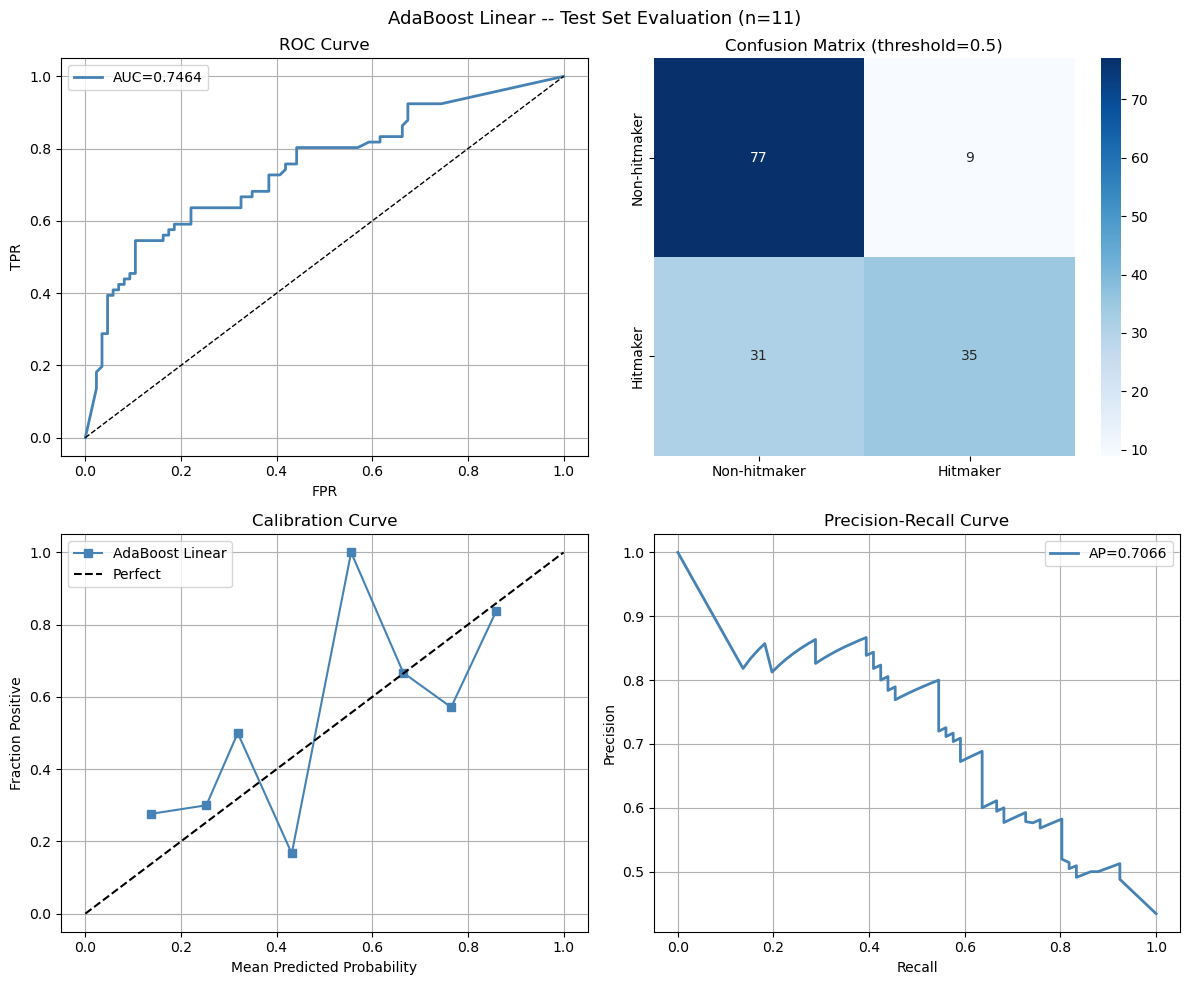

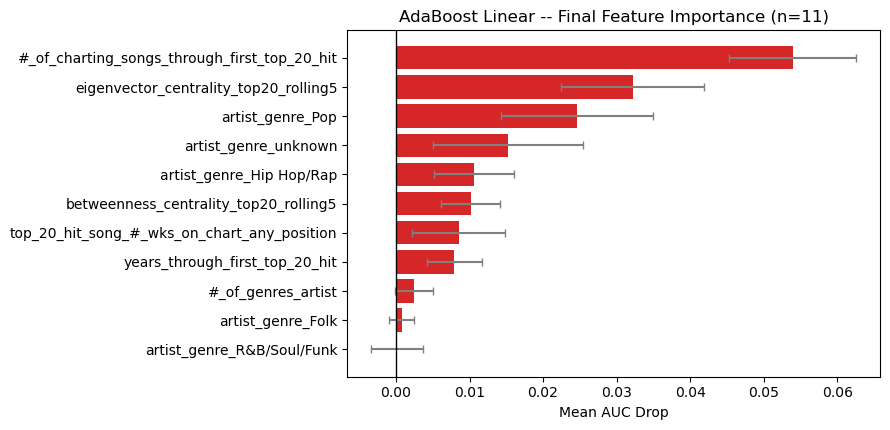


Feature direction:
                                              Perm Importance  Mean (hitmakers)  Mean (non-hitmakers)         Direction
#_of_charting_songs_through_first_top_20_hit           0.0539            0.2562               -0.1945    up -> Hitmaker
eigenvector_centrality_top20_rolling5                  0.0322            0.3026               -0.2298    up -> Hitmaker
artist_genre_Pop                                       0.0246            0.2080               -0.1579    up -> Hitmaker
artist_genre_unknown                                   0.0152           -0.2756                0.2093  down -> Hitmaker
artist_genre_Hip Hop/Rap                               0.0106            0.2872               -0.2181    up -> Hitmaker
betweenness_centrality_top20_rolling5                  0.0102            0.2584               -0.1962    up -> Hitmaker
top_20_hit_song_#_wks_on_chart_any_position            0.0085            0.1713               -0.1301    up -> Hitmaker
years_through_first_

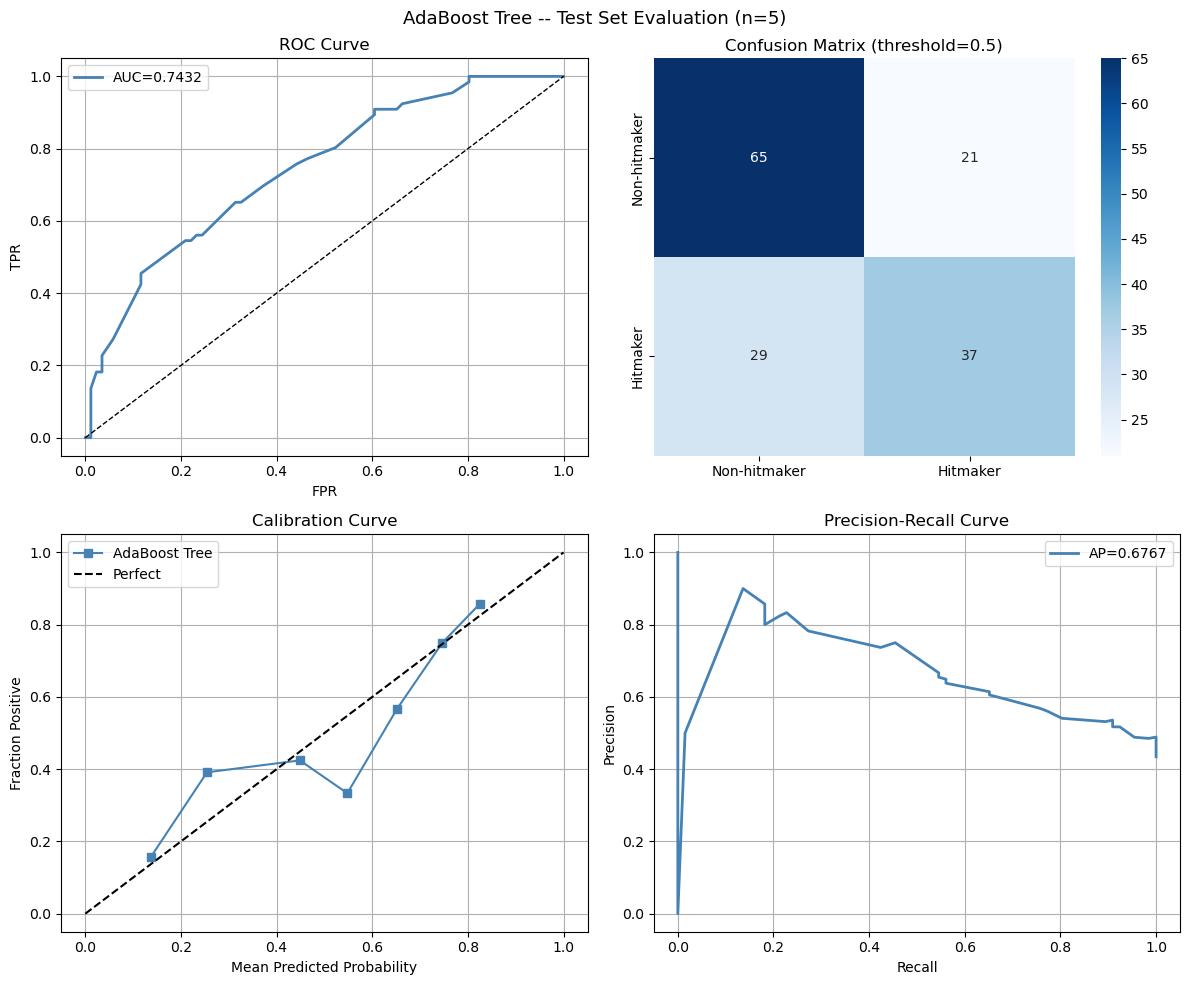

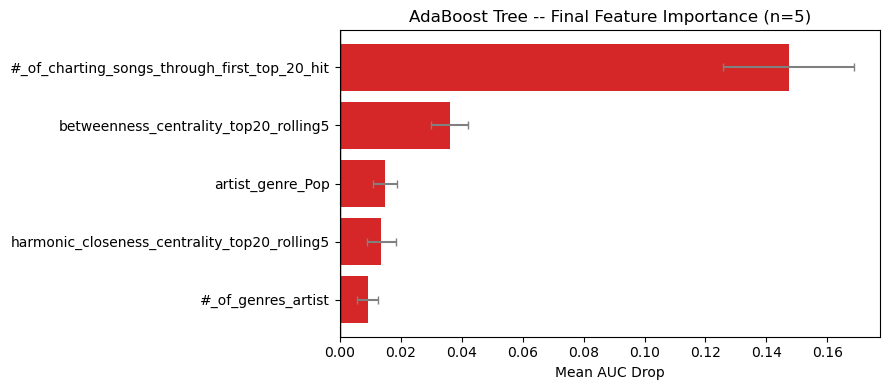


Feature direction:
                                              Perm Importance  Mean (hitmakers)  Mean (non-hitmakers)       Direction
#_of_charting_songs_through_first_top_20_hit           0.1473            3.9046                2.1275  up -> Hitmaker
betweenness_centrality_top20_rolling5                  0.0361            0.0015                0.0005  up -> Hitmaker
artist_genre_Pop                                       0.0148            0.5916                0.4087  up -> Hitmaker
harmonic_closeness_centrality_top20_rolling5           0.0137         2825.9863             1936.7885  up -> Hitmaker
#_of_genres_artist                                     0.0092            2.3168                1.7101  up -> Hitmaker

  FINAL MODEL: Random Forest  (n=9 features)
  Test AUC: 0.7671  Train AUC: 0.7720  Gap: 0.0050
  Log Loss: 0.5961  Brier: 0.2048
                precision    recall  f1-score   support

One-hit Wonder       0.73      0.64      0.68        86
      Hitmaker       0.60   

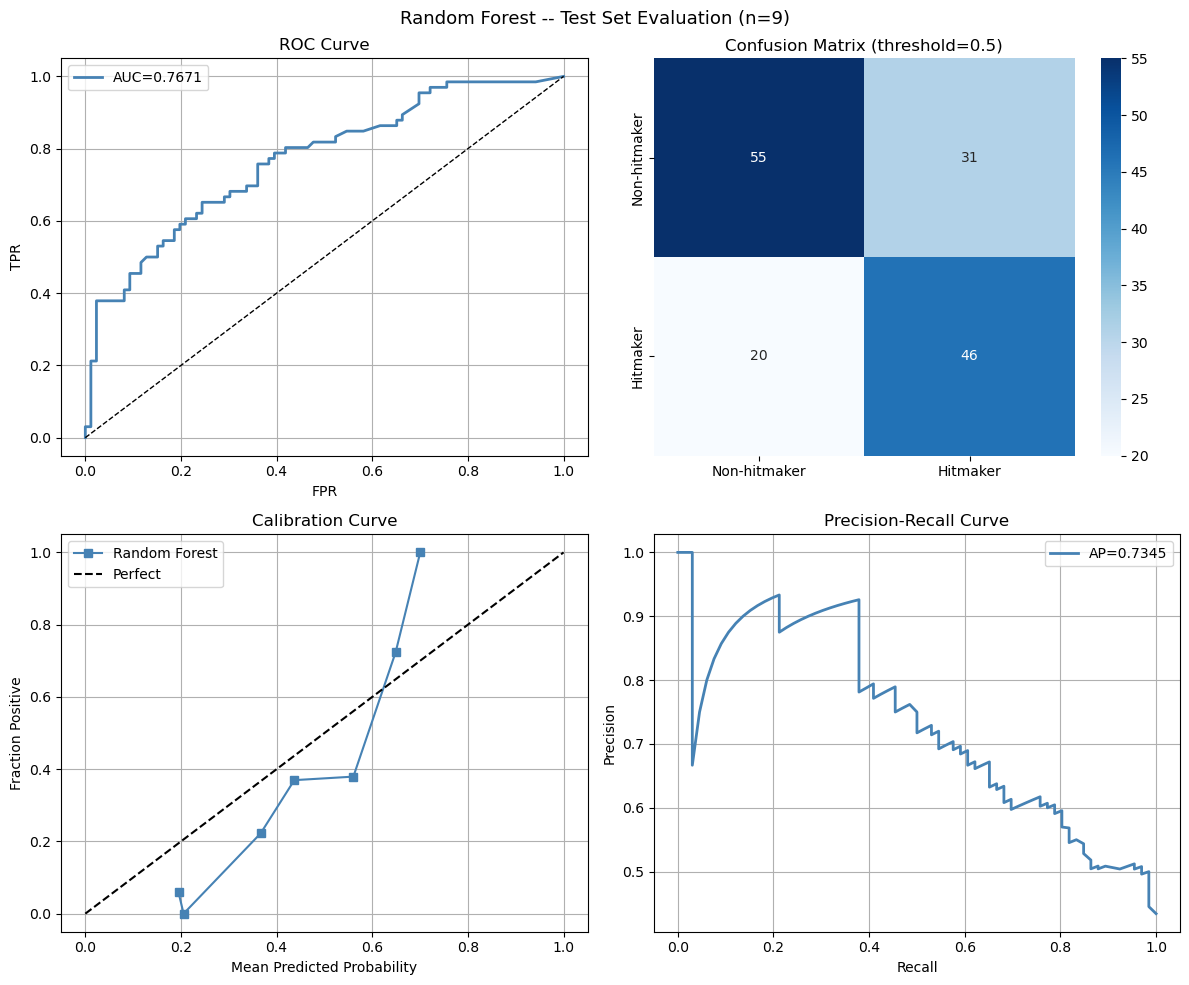

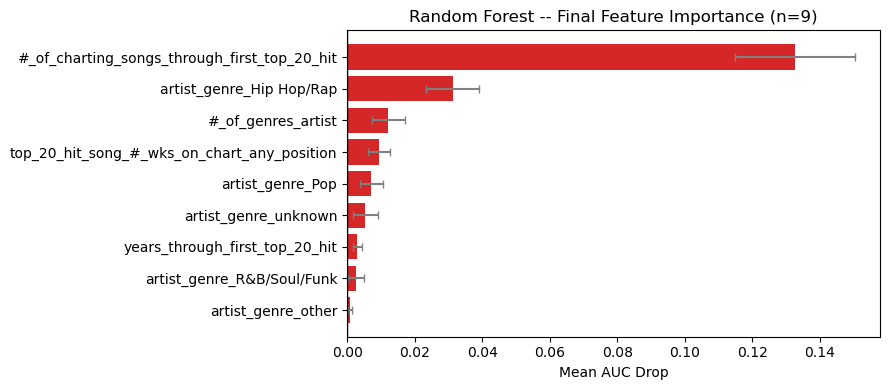


Feature direction:
                                              Perm Importance  Mean (hitmakers)  Mean (non-hitmakers)         Direction
#_of_charting_songs_through_first_top_20_hit           0.1325            3.9046                2.1275    up -> Hitmaker
artist_genre_Hip Hop/Rap                               0.0312            0.5076                0.2638    up -> Hitmaker
#_of_genres_artist                                     0.0122            2.3168                1.7101    up -> Hitmaker
top_20_hit_song_#_wks_on_chart_any_position            0.0094           29.9198               26.4174    up -> Hitmaker
artist_genre_Pop                                       0.0072            0.5916                0.4087    up -> Hitmaker
artist_genre_unknown                                   0.0054            0.0802                0.2696  down -> Hitmaker
years_through_first_top_20_hit                         0.0030            2.1260                2.0319    up -> Hitmaker
artist_genre_R&B/Sou

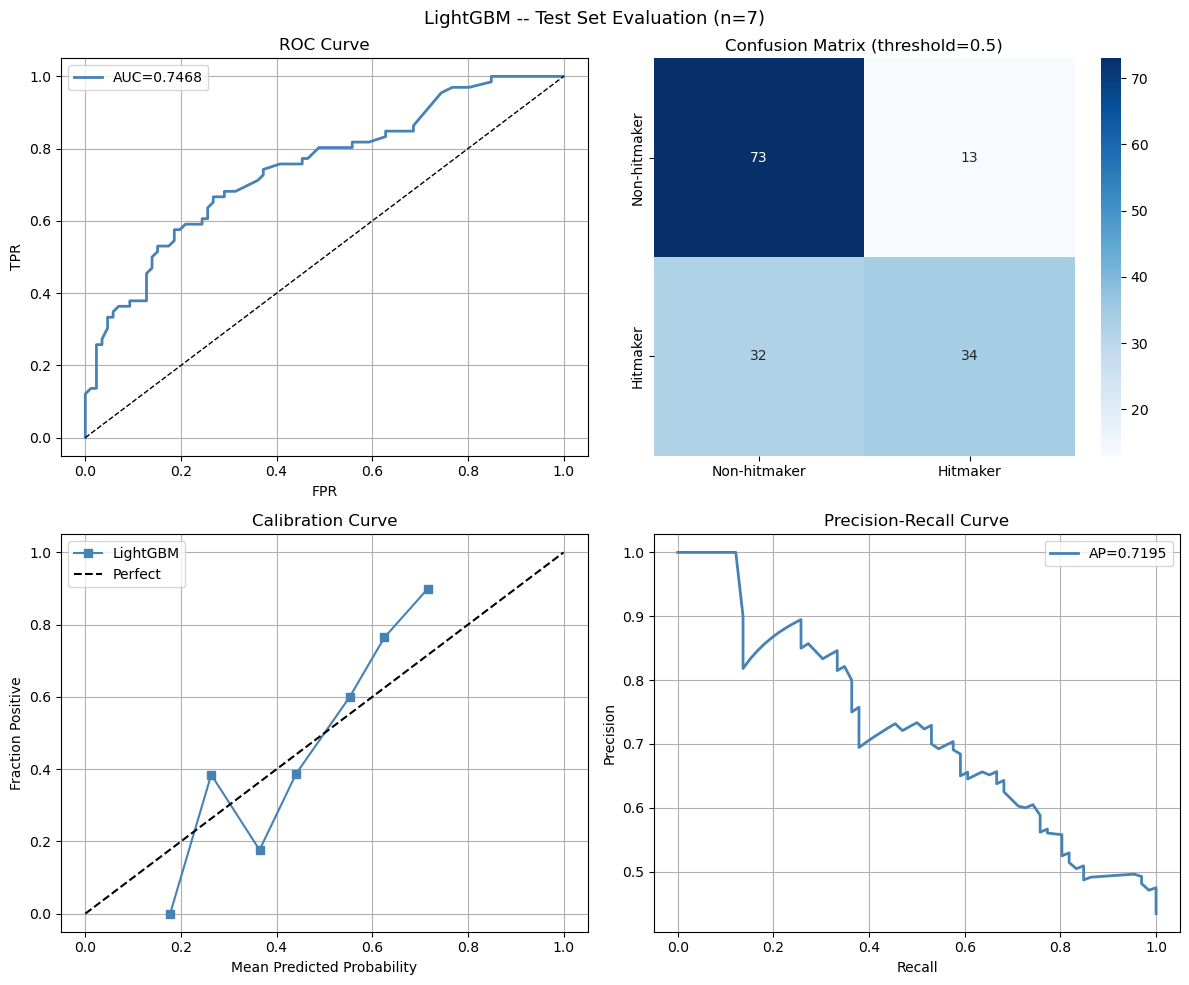

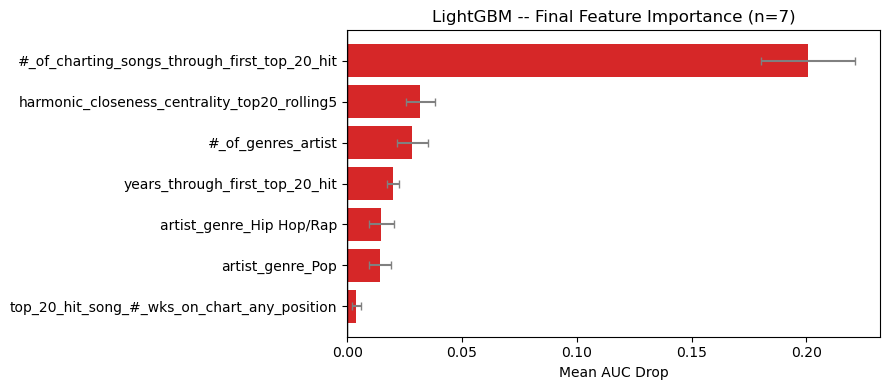


Feature direction:
                                              Perm Importance  Mean (hitmakers)  Mean (non-hitmakers)       Direction
#_of_charting_songs_through_first_top_20_hit           0.2007            3.9046                2.1275  up -> Hitmaker
harmonic_closeness_centrality_top20_rolling5           0.0317         2825.9863             1936.7885  up -> Hitmaker
#_of_genres_artist                                     0.0284            2.3168                1.7101  up -> Hitmaker
years_through_first_top_20_hit                         0.0201            2.1260                2.0319  up -> Hitmaker
artist_genre_Hip Hop/Rap                               0.0149            0.5076                0.2638  up -> Hitmaker
artist_genre_Pop                                       0.0143            0.5916                0.4087  up -> Hitmaker
top_20_hit_song_#_wks_on_chart_any_position            0.0039           29.9198               26.4174  up -> Hitmaker

  FINAL MODEL: XGBoost  (n=7 featur

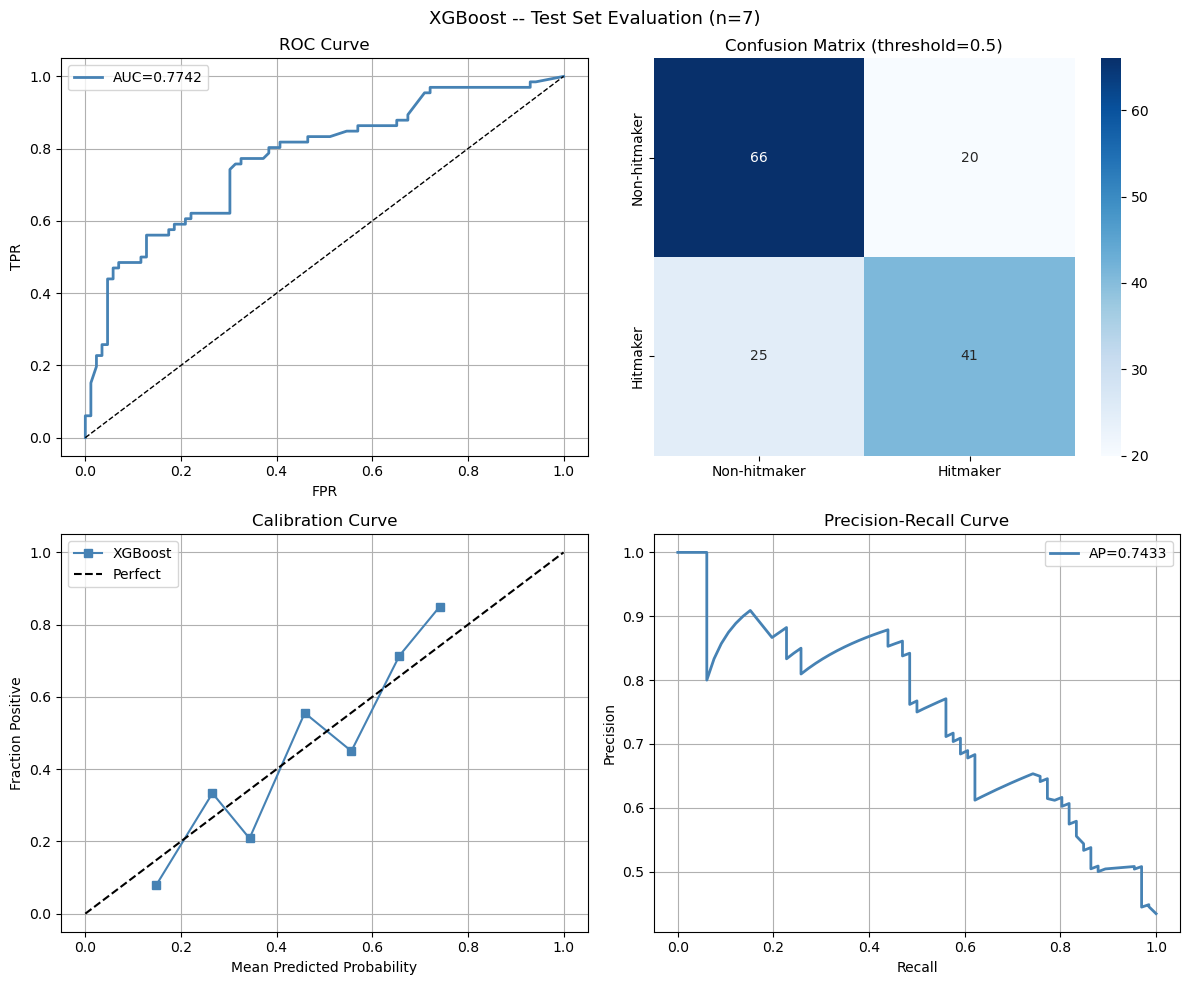

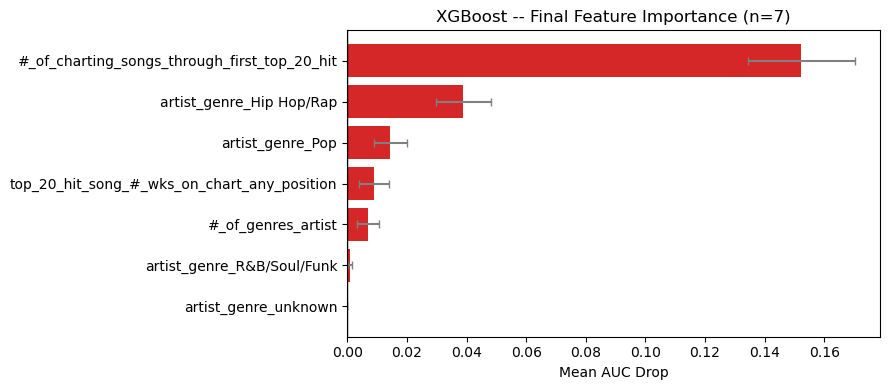


Feature direction:
                                              Perm Importance  Mean (hitmakers)  Mean (non-hitmakers)         Direction
#_of_charting_songs_through_first_top_20_hit           0.1523            3.9046                2.1275    up -> Hitmaker
artist_genre_Hip Hop/Rap                               0.0390            0.5076                0.2638    up -> Hitmaker
artist_genre_Pop                                       0.0145            0.5916                0.4087    up -> Hitmaker
top_20_hit_song_#_wks_on_chart_any_position            0.0089           29.9198               26.4174    up -> Hitmaker
#_of_genres_artist                                     0.0069            2.3168                1.7101    up -> Hitmaker
artist_genre_R&B/Soul/Funk                             0.0009            0.3206                0.1652    up -> Hitmaker
artist_genre_unknown                                   0.0000            0.0802                0.2696  down -> Hitmaker

  FINAL MODEL: CatB

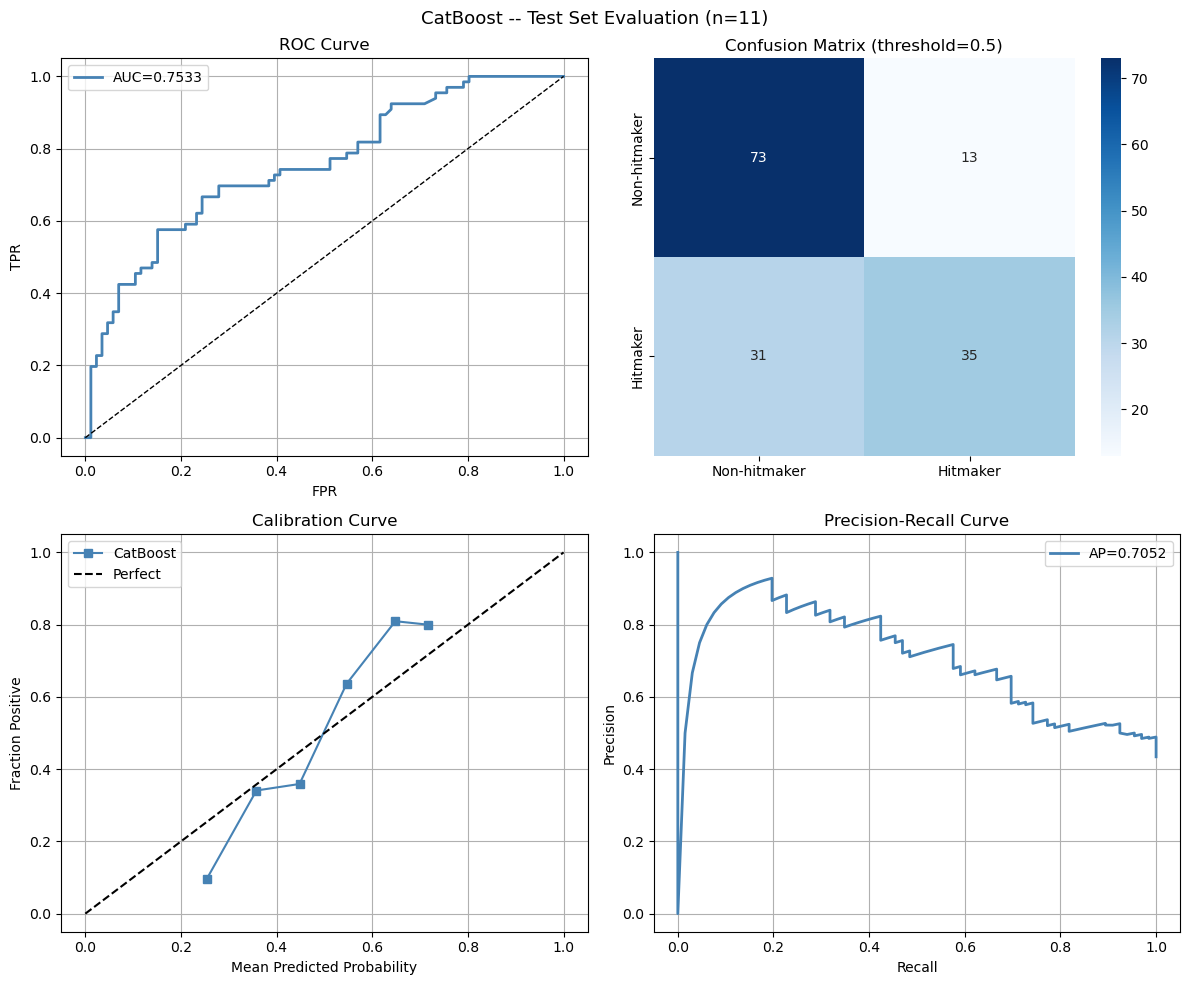

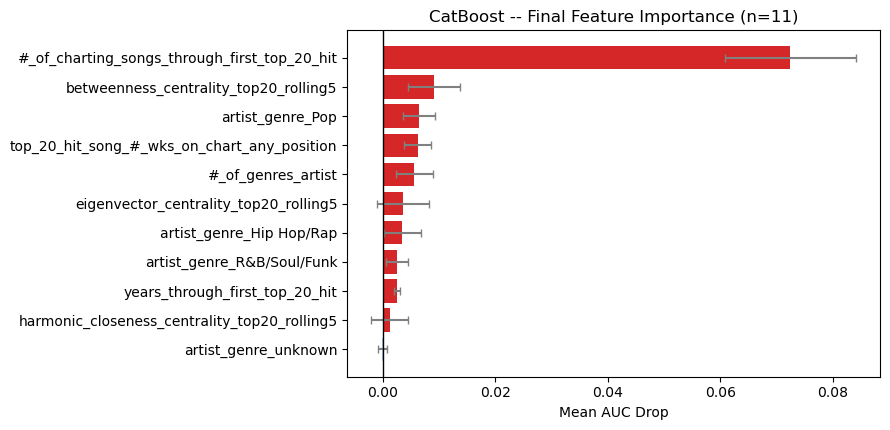


Feature direction:
                                              Perm Importance  Mean (hitmakers)  Mean (non-hitmakers)         Direction
#_of_charting_songs_through_first_top_20_hit           0.0724            3.9046                2.1275    up -> Hitmaker
betweenness_centrality_top20_rolling5                  0.0091            0.0015                0.0005    up -> Hitmaker
artist_genre_Pop                                       0.0064            0.5916                0.4087    up -> Hitmaker
top_20_hit_song_#_wks_on_chart_any_position            0.0062           29.9198               26.4174    up -> Hitmaker
#_of_genres_artist                                     0.0056            2.3168                1.7101    up -> Hitmaker
eigenvector_centrality_top20_rolling5                  0.0036            0.0172                0.0043    up -> Hitmaker
artist_genre_Hip Hop/Rap                               0.0035            0.5076                0.2638    up -> Hitmaker
artist_genre_R&B/Sou

In [78]:
# Fit each final model on the full training set (n_optimal features, tuned params).
# Evaluate once on the held-out test set -- this is the only time the test set
# is used for reporting, ensuring an unbiased estimate of generalization performance.
# Produces per-model: ROC curve, confusion matrix, calibration curve, PR curve.
# Also computes permutation importance on the training set for the final feature set
# (used in the cross-model heatmap and for feature direction analysis).

def compute_lift(y_true, y_proba):
    """Cumulative gain and lift at each probability rank threshold."""
    n         = len(y_true)
    total_pos = np.sum(y_true)
    sorted_idx = np.argsort(y_proba)[::-1]
    y_sorted   = np.array(y_true)[sorted_idx]
    cum_pos    = np.cumsum(y_sorted)
    pop_frac   = np.arange(1, n + 1) / n
    gain       = cum_pos / total_pos
    lift       = gain / pop_frac
    return pop_frac, gain, lift

for name in MODEL_NAMES:
    print(f'\n{"="*60}')
    print(f'  FINAL MODEL: {name}  (n={PIPE[name]["n_optimal"]} features)')
    print(f'{"="*60}')
    X_tr   = PIPE[name]['X_train_final']
    X_te   = PIPE[name]['X_test_final']
    params = PIPE[name]['params_final']

    model = build_model(name, params)
    model.fit(X_tr, y_train)
    PIPE[name]['model_final'] = model

    y_proba_te = model.predict_proba(X_te)[:, 1]
    y_proba_tr = model.predict_proba(X_tr)[:, 1]
    y_pred_50  = (y_proba_te >= 0.5).astype(int)

    PIPE[name]['y_proba_te'] = y_proba_te
    PIPE[name]['y_proba_tr'] = y_proba_tr
    PIPE[name]['test_auc']   = roc_auc_score(y_test, y_proba_te)
    PIPE[name]['train_auc']  = roc_auc_score(y_train, y_proba_tr)
    PIPE[name]['gap']        = PIPE[name]['train_auc'] - PIPE[name]['test_auc']
    PIPE[name]['logloss']    = log_loss(y_test, y_proba_te)
    PIPE[name]['brier']      = brier_score_loss(y_test, y_proba_te)

    print(f'  Test AUC: {PIPE[name]["test_auc"]:.4f}  Train AUC: {PIPE[name]["train_auc"]:.4f}  Gap: {PIPE[name]["gap"]:.4f}')
    print(f'  Log Loss: {PIPE[name]["logloss"]:.4f}  Brier: {PIPE[name]["brier"]:.4f}')
    print(classification_report(y_test, y_pred_50, target_names=['One-hit Wonder', 'Hitmaker']))

    cm = confusion_matrix(y_test, y_pred_50)
    fig, axes = plt.subplots(2, 2, figsize=(12, 10))

    fpr, tpr, _ = roc_curve(y_test, y_proba_te)
    axes[0,0].plot(fpr, tpr, color='steelblue', lw=2, label=f'AUC={PIPE[name]["test_auc"]:.4f}')
    axes[0,0].plot([0,1],[0,1],'k--',lw=1)
    axes[0,0].set_xlabel('FPR'); axes[0,0].set_ylabel('TPR')
    axes[0,0].set_title('ROC Curve'); axes[0,0].legend(); axes[0,0].grid(True)

    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0,1],
                xticklabels=['Non-hitmaker','Hitmaker'],
                yticklabels=['Non-hitmaker','Hitmaker'])
    axes[0,1].set_title('Confusion Matrix (threshold=0.5)')

    frac_pos, mean_pred = calibration_curve(y_test, y_proba_te, n_bins=10)
    axes[1,0].plot(mean_pred, frac_pos, 's-', color='steelblue', label=name)
    axes[1,0].plot([0,1],[0,1],'k--',lw=1.5,label='Perfect')
    axes[1,0].set_xlabel('Mean Predicted Probability'); axes[1,0].set_ylabel('Fraction Positive')
    axes[1,0].set_title('Calibration Curve'); axes[1,0].legend(); axes[1,0].grid(True)

    prec_v, rec_v, _ = precision_recall_curve(y_test, y_proba_te)
    ap = average_precision_score(y_test, y_proba_te)
    axes[1,1].plot(rec_v, prec_v, color='steelblue', lw=2, label=f'AP={ap:.4f}')
    axes[1,1].set_xlabel('Recall'); axes[1,1].set_ylabel('Precision')
    axes[1,1].set_title('Precision-Recall Curve'); axes[1,1].legend(); axes[1,1].grid(True)

    plt.suptitle(f'{name} -- Test Set Evaluation (n={PIPE[name]["n_optimal"]})', fontsize=13)
    plt.tight_layout(); plt.show()

    # Permutation importance on final feature set
    perm_fin = permutation_importance(
        model, X_tr, y_train,
        n_repeats=20, random_state=RANDOM_STATE, scoring='roc_auc',
    )
    perm_fin_df = pd.DataFrame({
        'Feature':    X_tr.columns,
        'Importance': perm_fin.importances_mean,
        'Std':        perm_fin.importances_std,
    }).sort_values('Importance', ascending=False).reset_index(drop=True)
    PIPE[name]['perm_final'] = perm_fin_df

    fig, ax = plt.subplots(figsize=(9, max(4, len(X_tr.columns) * 0.4)))
    df_p   = perm_fin_df.sort_values('Importance', ascending=True)
    colors = ['#d62728' if v > 0 else '#aec7e8' for v in df_p['Importance']]
    ax.barh(df_p['Feature'], df_p['Importance'], xerr=df_p['Std'],
            color=colors, error_kw={'ecolor': 'gray', 'capsize': 3})
    ax.axvline(0, color='black', lw=1)
    ax.set_xlabel('Mean AUC Drop')
    ax.set_title(f'{name} -- Final Feature Importance (n={PIPE[name]["n_optimal"]})')
    plt.tight_layout(); plt.show()

    # Feature direction table
    hm = y_train == 1
    dir_df = pd.DataFrame({
        'Perm Importance':      perm_fin_df.set_index('Feature')['Importance'],
        'Mean (hitmakers)':     X_tr[hm].mean(),
        'Mean (non-hitmakers)': X_tr[~hm].mean(),
    }).sort_values('Perm Importance', ascending=False).round(4)
    dir_df['Direction'] = (dir_df['Mean (hitmakers)'] > dir_df['Mean (non-hitmakers)']).map(
        {True: 'up -> Hitmaker', False: 'down -> Hitmaker'}
    )
    PIPE[name]['direction_df'] = dir_df
    print('\nFeature direction:')
    print(dir_df.to_string())

### Partial Dependence Plots

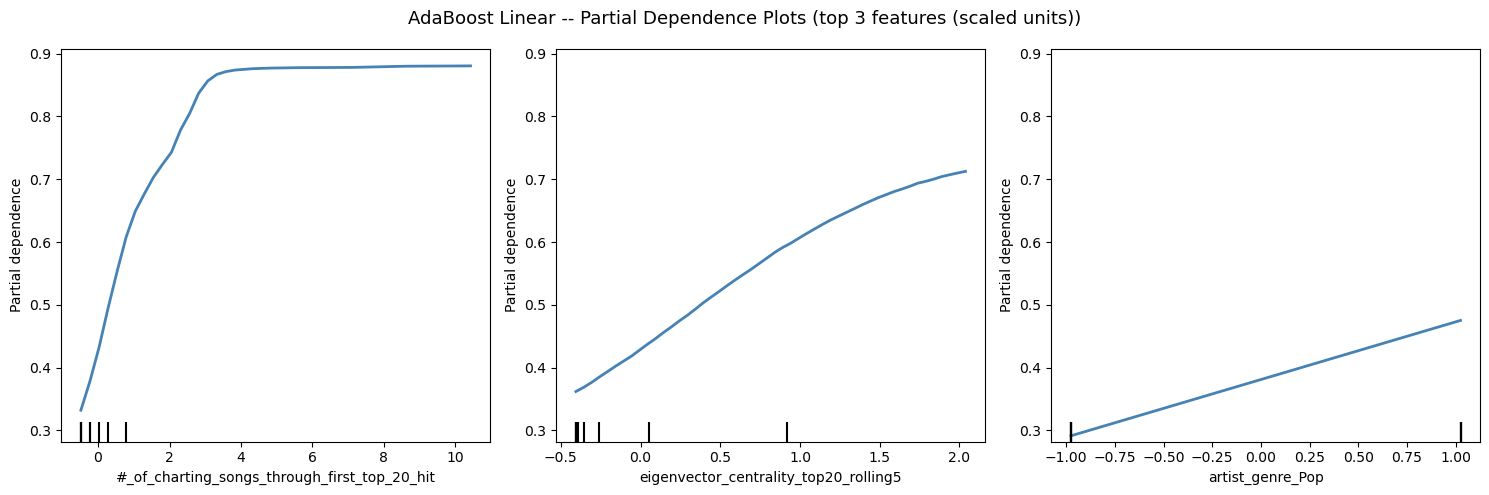

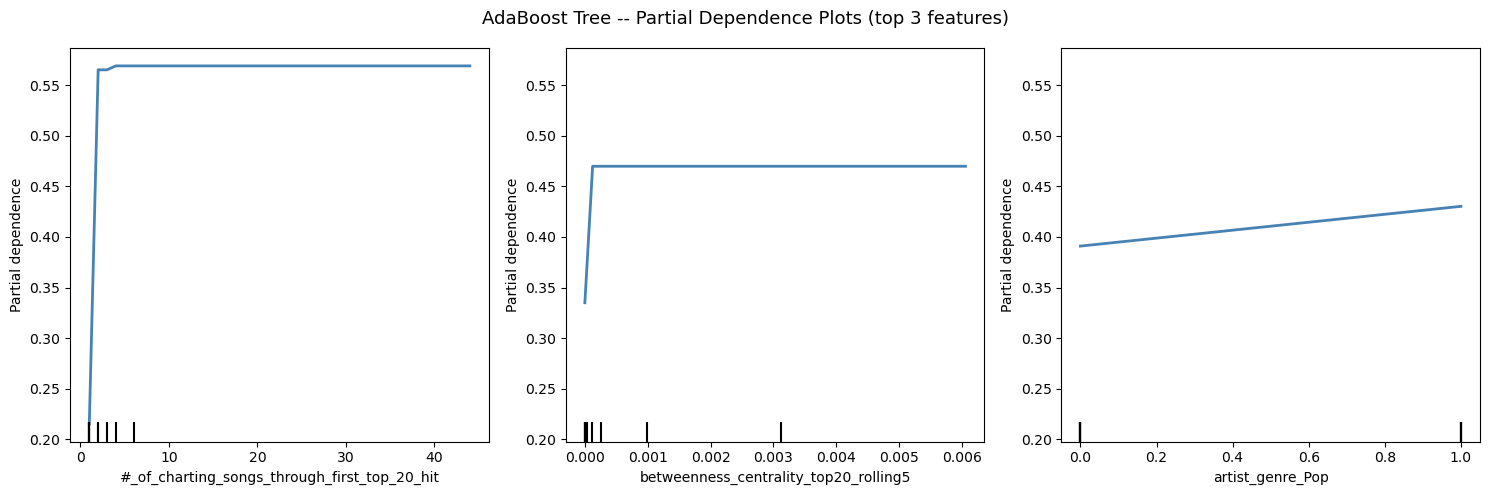

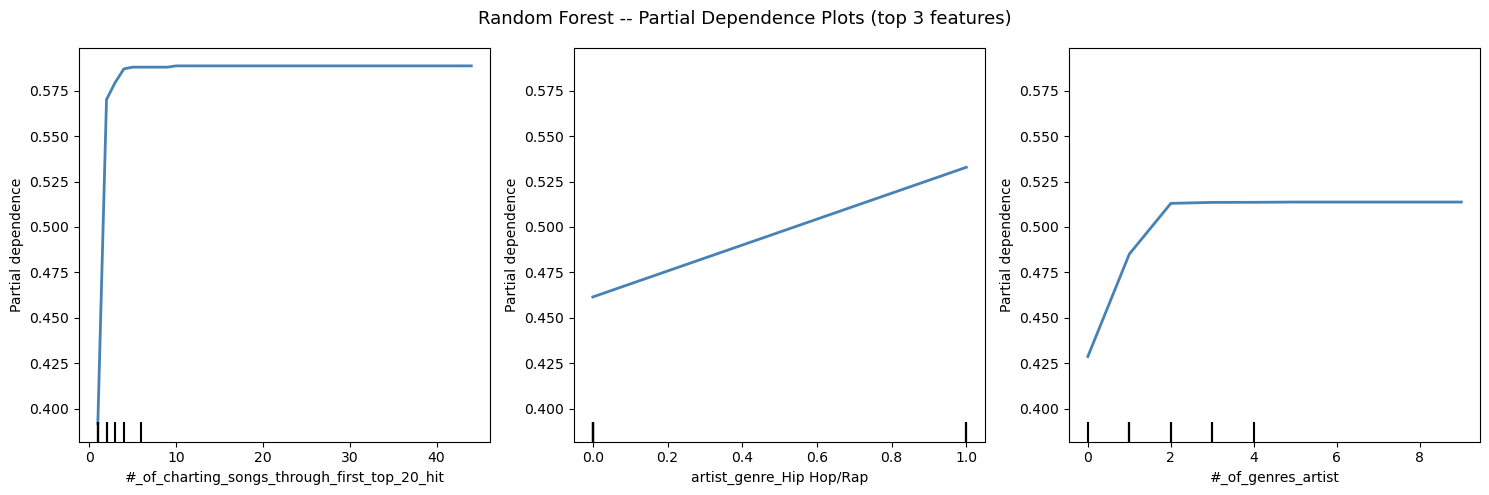

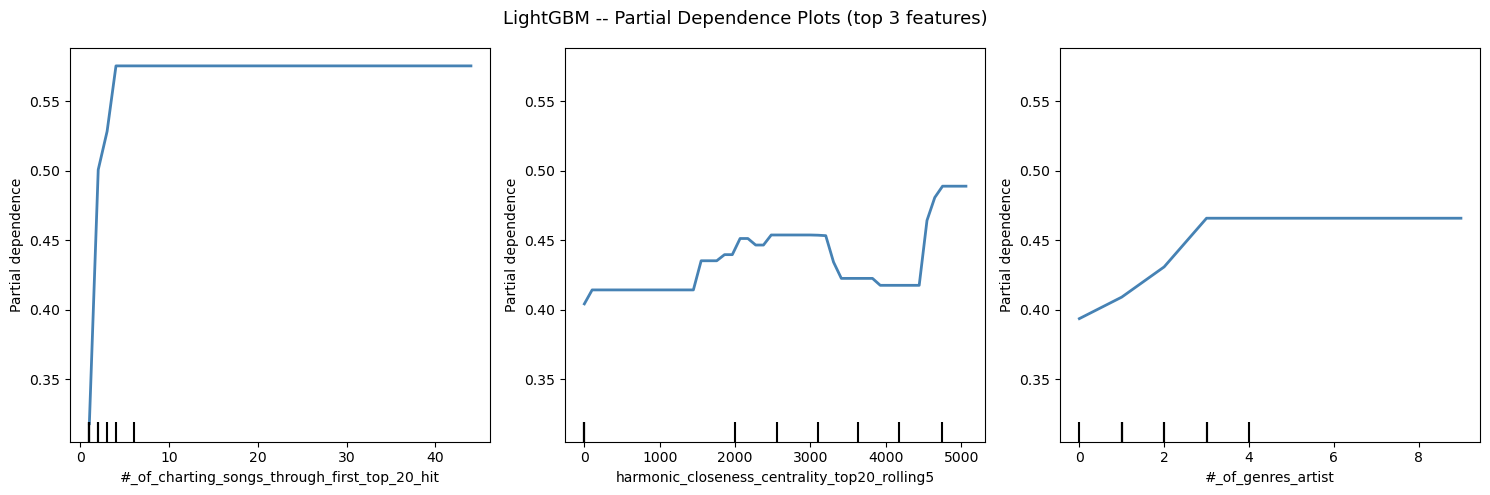

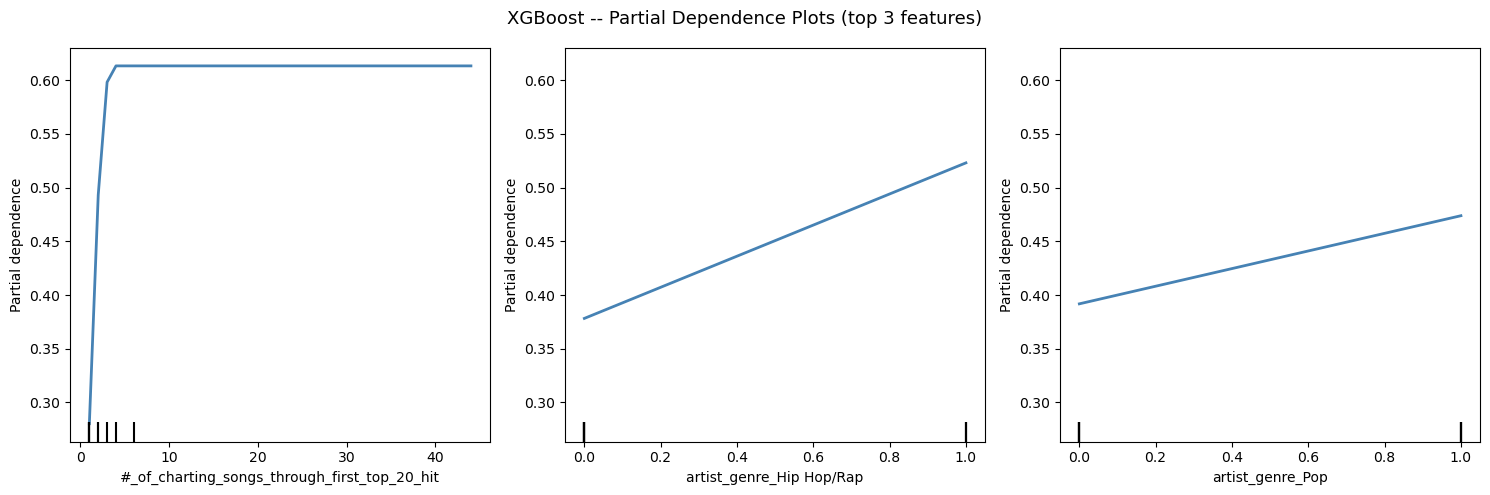

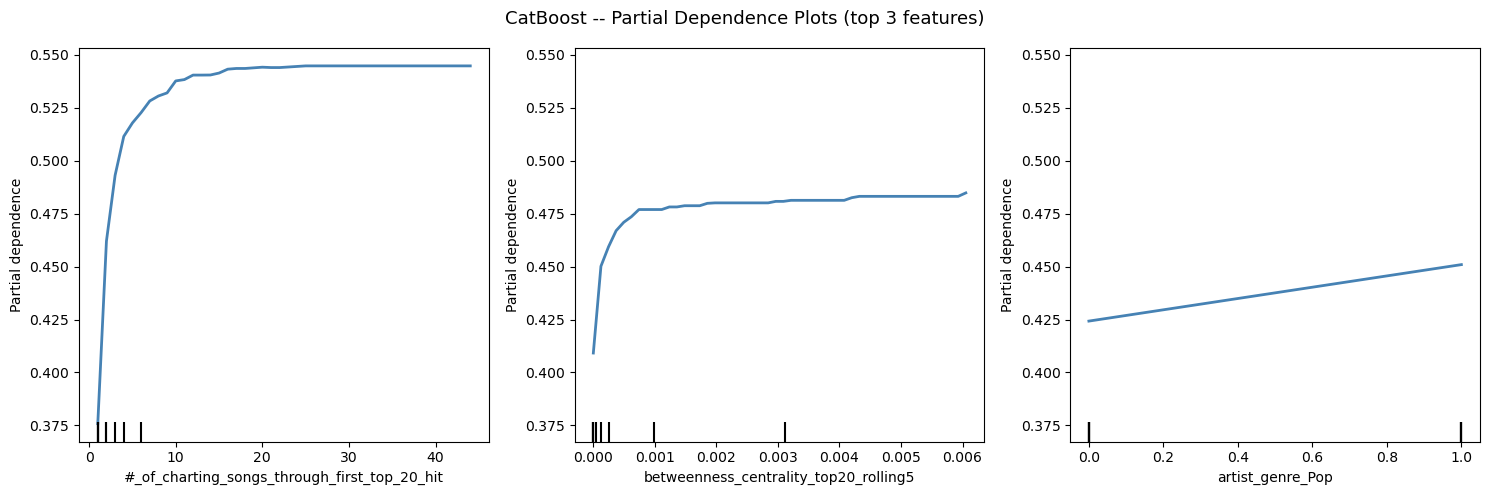

In [79]:
# PDPs show how predicted hitmaker probability changes as a single feature varies,
# while all other features are held at their average (marginal) values.
# This translates model behavior into plain language for stakeholders:
# 'as charting songs increases from 1 to 15, hitmaker probability rises from X to Y.'
# We plot the top 3 features by permutation importance for each model.
# Note: for AdaBoost Linear, x-axis values are on the StandardScaler scale
# (mean=0, std=1) rather than original units -- interpret directions, not magnitudes.

for name in MODEL_NAMES:
    model     = PIPE[name]['model_final']
    X_tr      = PIPE[name]['X_train_final']
    top_feats = PIPE[name]['perm_final']['Feature'].head(3).tolist()
    scale_note = ' (scaled units)' if MODEL_NEEDS_SCALER[name] else ''

    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    try:
        PartialDependenceDisplay.from_estimator(
            model, X_tr, features=top_feats,
            ax=axes, kind='average', grid_resolution=50,
            line_kw={'color': 'steelblue', 'lw': 2},
        )
        plt.suptitle(f'{name} -- Partial Dependence Plots (top 3 features{scale_note})', fontsize=13)
        plt.tight_layout(); plt.show()
    except Exception as e:
        print(f'{name}: PDP failed -- {e}')
        plt.close()

### Step 8 — OOF threshold tuning

AdaBoost Linear: threshold=0.28  P=0.689  R=0.636  F1=0.661
AdaBoost Tree: threshold=0.48  P=0.614  R=0.652  F1=0.632
Random Forest: threshold=0.49  P=0.617  R=0.758  F1=0.680
LightGBM: threshold=0.43  P=0.634  R=0.682  F1=0.657
XGBoost: threshold=0.44  P=0.649  R=0.727  F1=0.686
CatBoost: threshold=0.42  P=0.590  R=0.697  F1=0.639


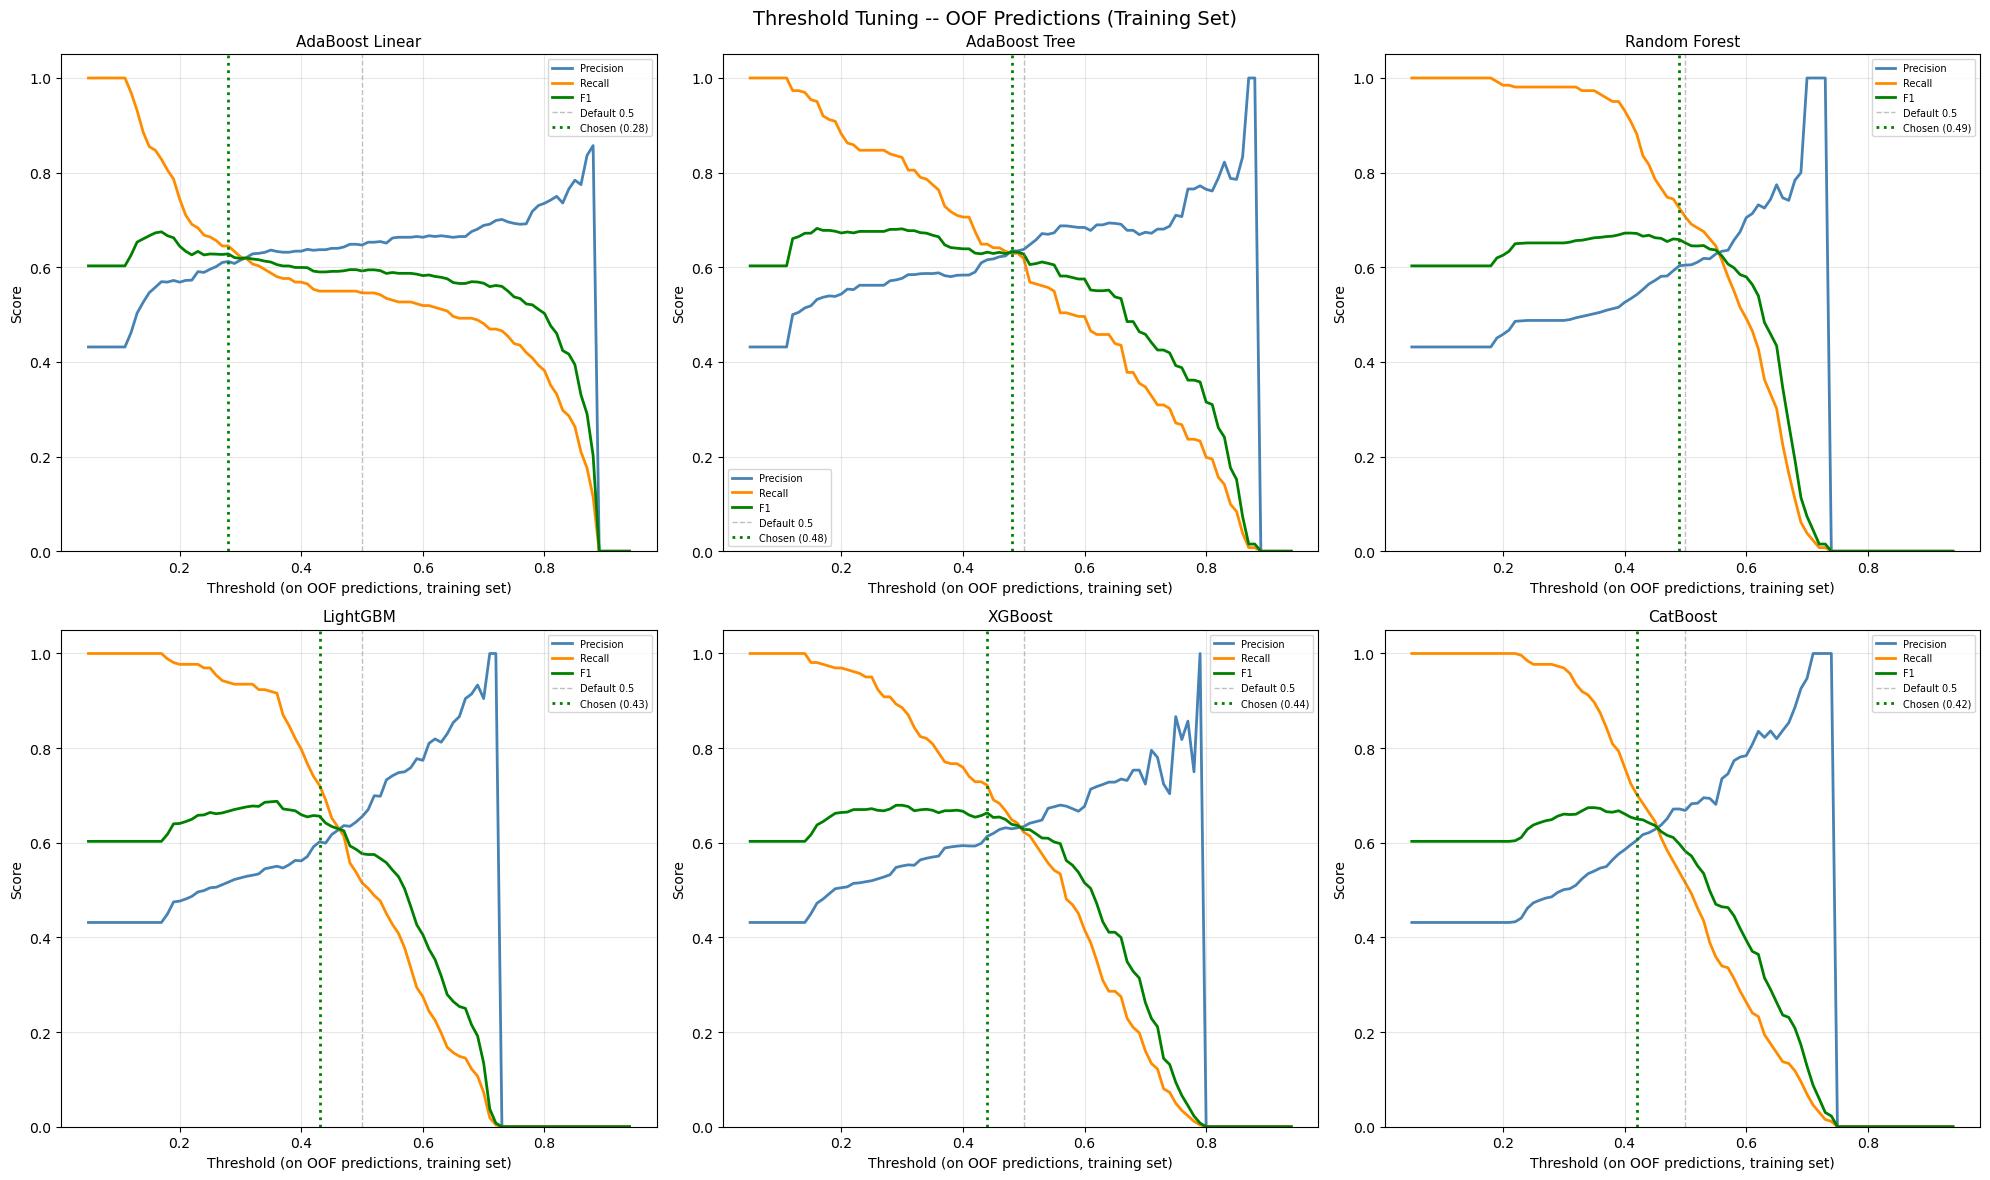

In [80]:
# Choosing the threshold by looking at test-set metrics is data leakage --
# the test set should be touched exactly once for final reporting.
# Instead, we generate out-of-fold (OOF) predictions on the training set:
# each fold's validation predictions come from a model that never saw that fold.
# We tune the threshold on OOF predictions, then apply to the test set only for
# final reporting.
# Fallback: if F1-peak threshold gives precision < 0.60, find the highest-F1
# threshold where precision >= 0.60 (avoids flagging too many false positives).

for name in MODEL_NAMES:
    X_tr   = PIPE[name]['X_train_final']
    params = PIPE[name]['params_final']

    oof_proba = np.zeros(len(y_train))
    for train_idx, val_idx in skf.split(X_tr, y_train):
        X_f, X_v = X_tr.iloc[train_idx], X_tr.iloc[val_idx]
        y_f, y_v = y_train.iloc[train_idx], y_train.iloc[val_idx]
        model = build_model(name, params)
        try:
            model.fit(X_f, y_f)
            oof_proba[val_idx] = model.predict_proba(X_v)[:, 1]
        except Exception:
            oof_proba[val_idx] = 0.5

    thresholds = np.arange(0.05, 0.95, 0.01)
    precs = np.array([precision_score(y_train, (oof_proba >= t).astype(int), zero_division=0) for t in thresholds])
    recs  = np.array([recall_score(y_train,    (oof_proba >= t).astype(int), zero_division=0) for t in thresholds])
    f1s   = np.array([f1_score(y_train,        (oof_proba >= t).astype(int), zero_division=0) for t in thresholds])

    best_idx = np.argmax(f1s)
    if precs[best_idx] < 0.60:
        valid_mask = precs >= 0.60
        best_idx   = np.argmax(np.where(valid_mask, f1s, 0)) if valid_mask.any() else np.argmin(np.abs(thresholds - 0.5))

    chosen_thresh = round(thresholds[best_idx], 2)
    PIPE[name]['threshold']  = chosen_thresh
    PIPE[name]['oof_proba']  = oof_proba

    y_proba_te = PIPE[name]['y_proba_te']
    y_pred_t   = (y_proba_te >= chosen_thresh).astype(int)
    PIPE[name]['precision_final'] = precision_score(y_test, y_pred_t)
    PIPE[name]['recall_final']    = recall_score(y_test, y_pred_t)
    PIPE[name]['f1_final']        = f1_score(y_test, y_pred_t)

    print(f'{name}: threshold={chosen_thresh}  '
          f'P={PIPE[name]["precision_final"]:.3f}  '
          f'R={PIPE[name]["recall_final"]:.3f}  '
          f'F1={PIPE[name]["f1_final"]:.3f}')

fig, axes = plt.subplots(2, 3, figsize=(20, 12))
for ax, name in zip(axes.flat, MODEL_NAMES):
    oof_p = PIPE[name]['oof_proba']
    ts    = np.arange(0.05, 0.95, 0.01)
    ps = [precision_score(y_train, (oof_p >= t).astype(int), zero_division=0) for t in ts]
    rs = [recall_score(y_train,    (oof_p >= t).astype(int), zero_division=0) for t in ts]
    fs = [f1_score(y_train,        (oof_p >= t).astype(int), zero_division=0) for t in ts]
    ax.plot(ts, ps, color='steelblue',  lw=2, label='Precision')
    ax.plot(ts, rs, color='darkorange', lw=2, label='Recall')
    ax.plot(ts, fs, color='green',      lw=2, label='F1')
    ax.axvline(0.5,                     color='gray',  linestyle='--', lw=1, alpha=0.5, label='Default 0.5')
    ax.axvline(PIPE[name]['threshold'], color='green', linestyle=':',  lw=2,
               label=f'Chosen ({PIPE[name]["threshold"]})')
    ax.set_title(name, fontsize=11)
    ax.set_xlabel('Threshold (on OOF predictions, training set)')
    ax.set_ylabel('Score')
    ax.legend(fontsize=7); ax.grid(True, alpha=0.3); ax.set_ylim(0, 1.05)
plt.suptitle('Threshold Tuning -- OOF Predictions (Training Set)', fontsize=14)
plt.tight_layout(); plt.show()

### Lift Curves & Prediction Tables

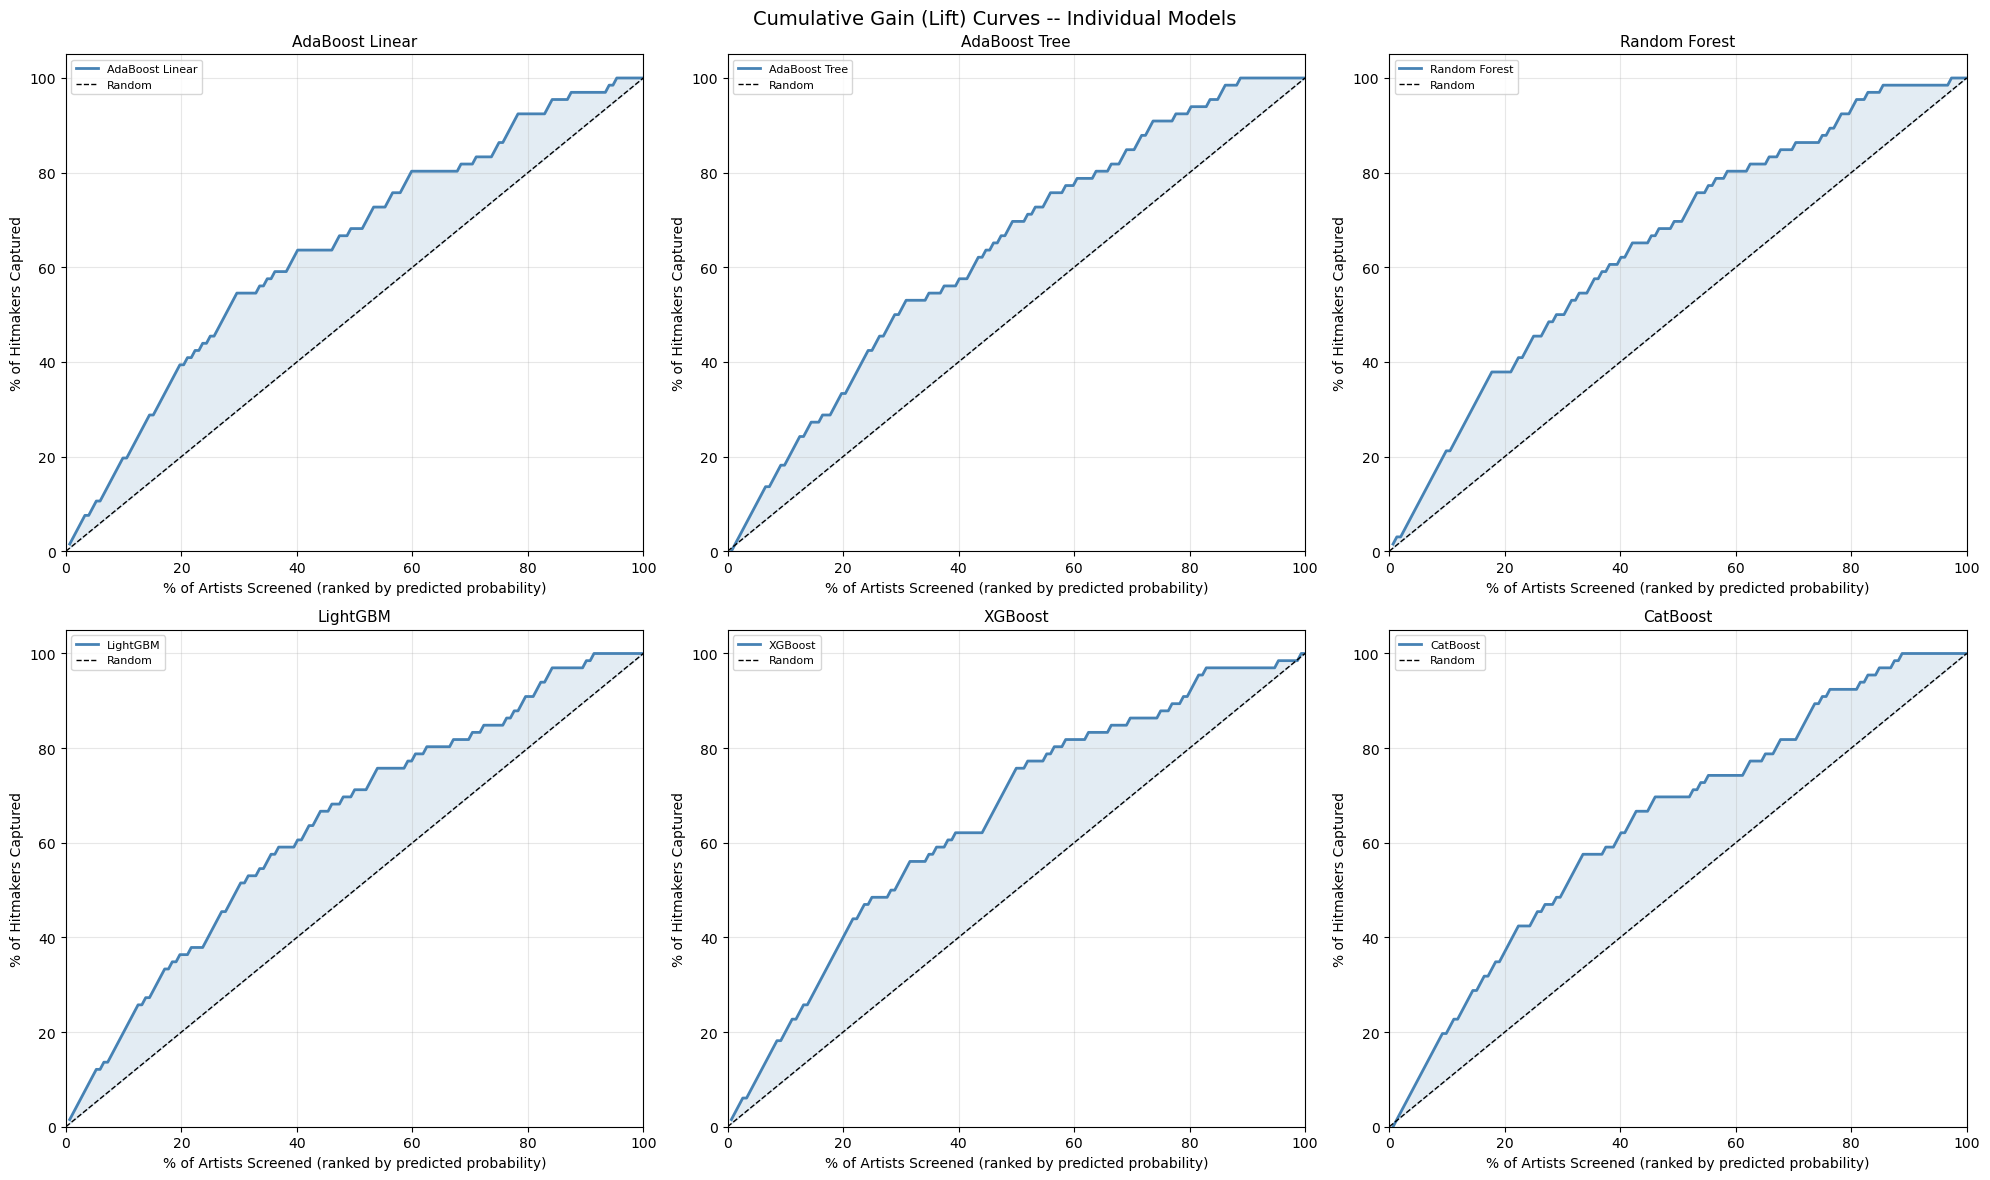


-- AdaBoost Linear (threshold=0.28) -- Accuracy=0.717  FP=19  FN=24 --
 index  True Label  Predicted Prob  Predicted Label       Error Type
   573         1.0           0.881                1          Correct
   582         1.0           0.881                1          Correct
   589         0.0           0.881                1 FP (false alarm)
    68         1.0           0.881                1          Correct
   419         1.0           0.881                1          Correct
   355         1.0           0.881                1          Correct
   746         1.0           0.881                1          Correct
   532         1.0           0.881                1          Correct
   515         1.0           0.881                1          Correct
   155         1.0           0.881                1          Correct
   177         0.0           0.881                1 FP (false alarm)
   593         1.0           0.877                1          Correct
   251         1.0           0.

In [81]:
# Lift curve: at each percentile of the ranked probability list, how many times
# better are we than random at identifying hitmakers?
# 'Screening the top 30% of artists flagged by the model captures X% of all
# hitmakers -- Y times better than randomly selecting 30%.'
# This is the most intuitive metric for stakeholders making resource allocation
# decisions (e.g. which artists to invest in or sign).
#
# Prediction table: full test-set ranking with predicted probability, true label,
# and error type. Sorted by predicted probability descending.
# Useful for spotting systematic errors and for presentation moments.

fig, axes = plt.subplots(2, 3, figsize=(20, 12))
for ax, name in zip(axes.flat, MODEL_NAMES):
    y_p = PIPE[name]['y_proba_te']
    pop_frac, gain, _ = compute_lift(y_test.values, y_p)
    ax.plot(pop_frac * 100, gain * 100, color='steelblue', lw=2, label=name)
    ax.plot([0, 100], [0, 100], 'k--', lw=1, label='Random')
    ax.fill_between(pop_frac * 100, gain * 100, pop_frac * 100, alpha=0.15, color='steelblue')
    ax.set_xlabel('% of Artists Screened (ranked by predicted probability)')
    ax.set_ylabel('% of Hitmakers Captured')
    ax.set_title(name, fontsize=11)
    ax.legend(fontsize=8); ax.grid(True, alpha=0.3)
    ax.set_xlim(0, 100); ax.set_ylim(0, 105)
plt.suptitle('Cumulative Gain (Lift) Curves -- Individual Models', fontsize=14)
plt.tight_layout(); plt.show()

for name in MODEL_NAMES:
    thresh = PIPE[name]['threshold']
    y_p    = PIPE[name]['y_proba_te']
    y_pred = (y_p >= thresh).astype(int)
    pred_table = pd.DataFrame({
        'True Label':      y_test.values,
        'Predicted Prob':  y_p.round(3),
        'Predicted Label': y_pred,
        'Correct':         (y_test.values == y_pred).astype(int),
        'Error Type':      np.where(y_test.values == y_pred, 'Correct',
                           np.where((y_test.values == 0) & (y_pred == 1),
                                    'FP (false alarm)', 'FN (missed hitmaker)')),
    }, index=y_test.index).sort_values('Predicted Prob', ascending=False).reset_index()
    PIPE[name]['pred_table'] = pred_table
    acc = pred_table['Correct'].mean()
    fp  = (pred_table['Error Type'] == 'FP (false alarm)').sum()
    fn  = (pred_table['Error Type'] == 'FN (missed hitmaker)').sum()
    print(f'\n-- {name} (threshold={thresh}) -- Accuracy={acc:.3f}  FP={fp}  FN={fn} --')
    print(pred_table[['index','True Label','Predicted Prob','Predicted Label','Error Type']]
          .head(20).to_string(index=False))

## Cross-model comparison

Cross-Model Comparison (OOF-tuned thresholds):
                 N Features  Threshold             CV AUC  Test AUC  Overfit Gap  Log Loss  Brier Score  Precision  Recall     F1
Model                                                                                                                            
AdaBoost Linear          11       0.28  0.7411 +/- 0.0201    0.7464       0.0078    0.6078       0.2040      0.689   0.636  0.661
AdaBoost Tree             5       0.48  0.7547 +/- 0.0289    0.7432       0.0285    0.6018       0.2075      0.614   0.652  0.632
Random Forest             9       0.49  0.7551 +/- 0.0296    0.7671       0.0050    0.5961       0.2048      0.617   0.758  0.680
LightGBM                  7       0.43  0.7590 +/- 0.0333    0.7468       0.0567    0.5979       0.2054      0.634   0.682  0.657
XGBoost                   7       0.44  0.7530 +/- 0.0370    0.7742      -0.0032    0.5609       0.1891      0.649   0.727  0.686
CatBoost                 11       0.42  0.7

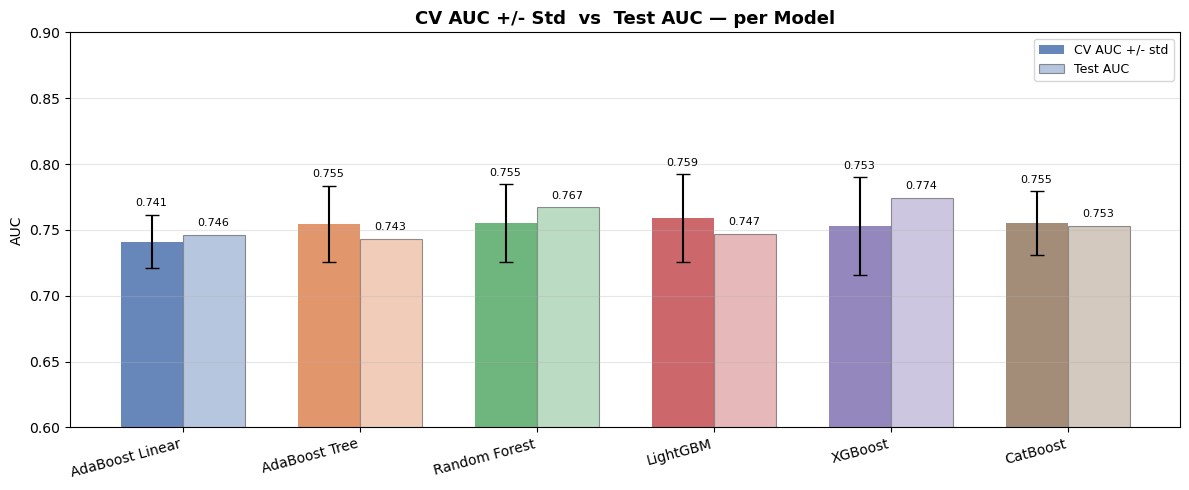

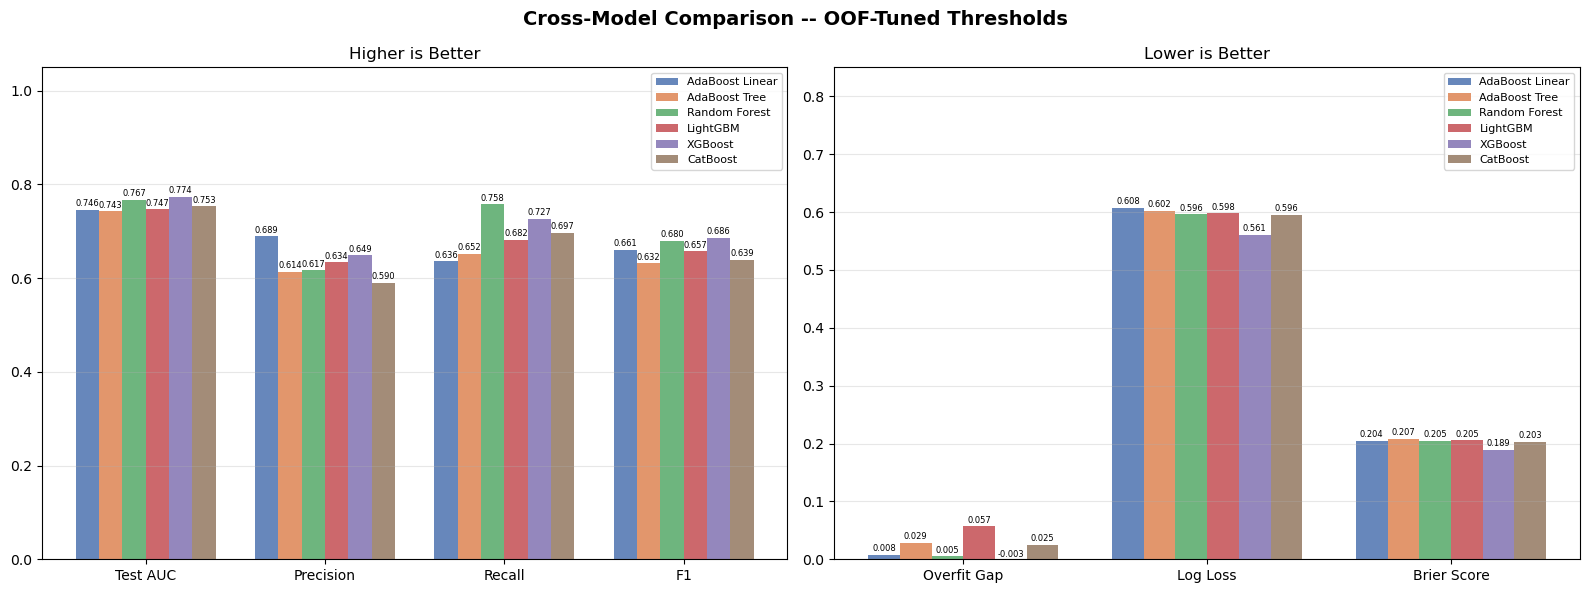

In [82]:
# All models compared on the same held-out test set with their OOF-tuned thresholds.
# CV AUC is reported as mean +/- std from the re-tune step at n_optimal.
#
# Figure 1 — CV AUC +/- std vs Test AUC:
#   Error bars show fold-to-fold variability in cross-validated AUC.
#   A wide error bar means performance is sensitive to which 20% is held out
#   -- less reliable when generalising to unseen data.
#   The gap between the CV AUC bar and the Test AUC bar visualises overfitting.
#
# Figure 2 — Other metrics (Precision, Recall, F1, Logloss, Brier, Gap).

rows = []
for name in MODEL_NAMES:
    n = PIPE[name]['n_optimal']
    r = PIPE[name]['cv_result_final']
    rows.append({
        'Model':       name,
        'N Features':  n,
        'Threshold':   PIPE[name]['threshold'],
        'CV AUC':      f'{r["CV AUC"]:.4f} +/- {r["CV AUC Std"]:.4f}',
        'Test AUC':    round(PIPE[name]['test_auc'], 4),
        'Overfit Gap': round(PIPE[name]['gap'], 4),
        'Log Loss':    round(PIPE[name]['logloss'], 4),
        'Brier Score': round(PIPE[name]['brier'], 4),
        'Precision':   round(PIPE[name]['precision_final'], 3),
        'Recall':      round(PIPE[name]['recall_final'], 3),
        'F1':          round(PIPE[name]['f1_final'], 3),
    })
df_compare = pd.DataFrame(rows).set_index('Model')
print('Cross-Model Comparison (OOF-tuned thresholds):')
print(df_compare.to_string())

palette = ['#4C72B0','#DD8452','#55A868','#C44E52','#8172B2','#937860']
c_map   = {name: c for name, c in zip(MODEL_NAMES, palette)}

# --- Figure 1: CV AUC +/- std vs Test AUC ---
cv_aucs   = [PIPE[n]['cv_result_final']['CV AUC']     for n in MODEL_NAMES]
cv_stds   = [PIPE[n]['cv_result_final']['CV AUC Std'] for n in MODEL_NAMES]
test_aucs = [PIPE[n]['test_auc'] for n in MODEL_NAMES]
colors    = [c_map[n] for n in MODEL_NAMES]

fig0, ax0 = plt.subplots(figsize=(12, 5))
x = np.arange(len(MODEL_NAMES))
w = 0.35
ax0.bar(x - w/2, cv_aucs, w, yerr=cv_stds, capsize=5,
        color=colors, alpha=0.85, label='CV AUC +/- std',
        error_kw={'ecolor': 'black', 'capsize': 5, 'elinewidth': 1.5})
ax0.bar(x + w/2, test_aucs, w,
        color=colors, alpha=0.40, label='Test AUC',
        edgecolor='black', linewidth=0.8)
for i, (cv, std, te) in enumerate(zip(cv_aucs, cv_stds, test_aucs)):
    ax0.text(x[i] - w/2, cv + std + 0.005, f'{cv:.3f}',
             ha='center', va='bottom', fontsize=8)
    ax0.text(x[i] + w/2, te + 0.005, f'{te:.3f}',
             ha='center', va='bottom', fontsize=8)
ax0.set_xticks(x)
ax0.set_xticklabels(MODEL_NAMES, rotation=15, ha='right')
ax0.set_ylim(0.60, 0.90)
ax0.set_ylabel('AUC')
ax0.set_title('CV AUC +/- Std  vs  Test AUC — per Model', fontsize=13, fontweight='bold')
ax0.legend(fontsize=9)
ax0.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

# --- Figure 2: Other metrics ---
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Cross-Model Comparison -- OOF-Tuned Thresholds', fontsize=14, fontweight='bold')

w       = 0.13
offsets = np.arange(len(MODEL_NAMES)) - (len(MODEL_NAMES) - 1) / 2
metrics_h = ['Test AUC', 'Precision', 'Recall', 'F1']
metrics_l = ['Overfit Gap', 'Log Loss', 'Brier Score']
x_h = np.arange(len(metrics_h))
x_l = np.arange(len(metrics_l))

for i, name in enumerate(MODEL_NAMES):
    vals_h = [df_compare.loc[name, m] for m in metrics_h]
    vals_l = [df_compare.loc[name, m] for m in metrics_l]
    for ax, vals, xs in [(axes[0], vals_h, x_h), (axes[1], vals_l, x_l)]:
        ax.bar(xs + offsets[i] * w, vals, w, label=name, color=c_map[name], alpha=0.85)
        for k, v in enumerate(vals):
            ax.text(xs[k] + offsets[i] * w, v + 0.003, f'{v:.3f}',
                    ha='center', va='bottom', fontsize=6)

axes[0].set_xticks(x_h); axes[0].set_xticklabels(metrics_h)
axes[0].set_ylim(0, 1.05); axes[0].set_title('Higher is Better')
axes[0].legend(fontsize=8); axes[0].grid(axis='y', alpha=0.3)

axes[1].set_xticks(x_l); axes[1].set_xticklabels(metrics_l)
axes[1].set_ylim(0, 0.85); axes[1].set_title('Lower is Better')
axes[1].legend(fontsize=8); axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()


In [83]:
# Model parameters and complexity comparison.
# Total Leaves = actual leaf nodes across all trees — the most direct measure
# of model capacity (more leaves = more decision boundaries = more complex).
# For AdaBoost Linear, base classifiers are linear (SGD) so leaves = N/A.

def get_key_params(name, params):
    if name == 'AdaBoost Linear':
        return dict(n_estimators=params.get('n_estimators'),
                    lr=round(params.get('learning_rate', 0), 4),
                    depth='— (linear)',
                    reg=f"α={params.get('alpha', 0):.1e}")
    elif name == 'AdaBoost Tree':
        return dict(n_estimators=params.get('n_estimators'),
                    lr=round(params.get('learning_rate', 0), 4),
                    depth=params.get('max_depth', 2),
                    reg='—')
    elif name == 'Random Forest':
        return dict(n_estimators=params.get('n_estimators'),
                    lr='—',
                    depth=params.get('max_depth'),
                    reg=f"min_leaf={params.get('min_samples_leaf')}")
    elif name == 'LightGBM':
        return dict(n_estimators=params.get('n_estimators'),
                    lr=round(params.get('learning_rate', 0), 4),
                    depth=params.get('max_depth'),
                    reg=f"λ={params.get('reg_lambda', 0):.2f}")
    elif name == 'XGBoost':
        return dict(n_estimators=params.get('n_estimators'),
                    lr=round(params.get('learning_rate', 0), 4),
                    depth=params.get('max_depth'),
                    reg=f"α={params.get('reg_alpha', 0):.2f} λ={params.get('reg_lambda', 0):.2f}")
    elif name == 'CatBoost':
        return dict(n_estimators=params.get('n_estimators'),
                    lr=round(params.get('learning_rate', 0), 4),
                    depth=params.get('depth'),
                    reg=f"l2={params.get('l2_leaf_reg', 0):.2f}")

def count_total_leaves(name, model, params):
    try:
        if name in ('Random Forest', 'AdaBoost Tree'):
            return sum(t.get_n_leaves() for t in model.estimators_)
        elif name == 'XGBoost':
            df_t = model.get_booster().trees_to_dataframe()
            return int((df_t['Feature'] == 'Leaf').sum())
        elif name == 'LightGBM':
            # num_leaves * num_trees (upper bound; actual may be lower for shallow trees)
            return model.booster_.num_trees() * params.get('num_leaves', 31)
        elif name == 'CatBoost':
            return int(sum(model.get_tree_leaf_counts()))
    except Exception as e:
        return f'err({e})'
    return '—'

rows = []
for name in MODEL_NAMES:
    model  = PIPE[name]['model_final']
    params = PIPE[name]['params_final']
    kp     = get_key_params(name, params)
    rows.append({
        'Model':          name,
        'N Features':     PIPE[name]['n_optimal'],
        'n_estimators':   kp['n_estimators'],
        'Depth':          kp['depth'],
        'Learning Rate':  kp['lr'],
        'Regularization': kp['reg'],
        'Total Leaves':   count_total_leaves(name, model, params),
        'CV AUC':         round(PIPE[name]['cv_result_final']['CV AUC'], 4),
        'Test AUC':       round(PIPE[name]['test_auc'], 4),
        'F1':             round(PIPE[name]['f1_final'], 3),
    })

df_complexity = pd.DataFrame(rows).set_index('Model')
print('Model Parameters & Complexity:')
print(df_complexity.to_string())


Model Parameters & Complexity:
                 N Features  n_estimators       Depth Learning Rate Regularization Total Leaves  CV AUC  Test AUC     F1
Model                                                                                                                   
AdaBoost Linear          11           257  — (linear)         0.107      α=1.0e-05            —  0.7411    0.7464  0.661
AdaBoost Tree             5           130           2        0.0158              —          520  0.7547    0.7432  0.632
Random Forest             9           409           2             —    min_leaf=17         1590  0.7551    0.7671  0.680
LightGBM                  7           237           9         0.005         λ=0.51         4503  0.7590    0.7468  0.657
XGBoost                   7           239           5        0.0238  α=0.36 λ=0.00          468  0.7530    0.7742  0.686
CatBoost                 11           359           2        0.0058        l2=9.19         1430  0.7550    0.7533  0.639


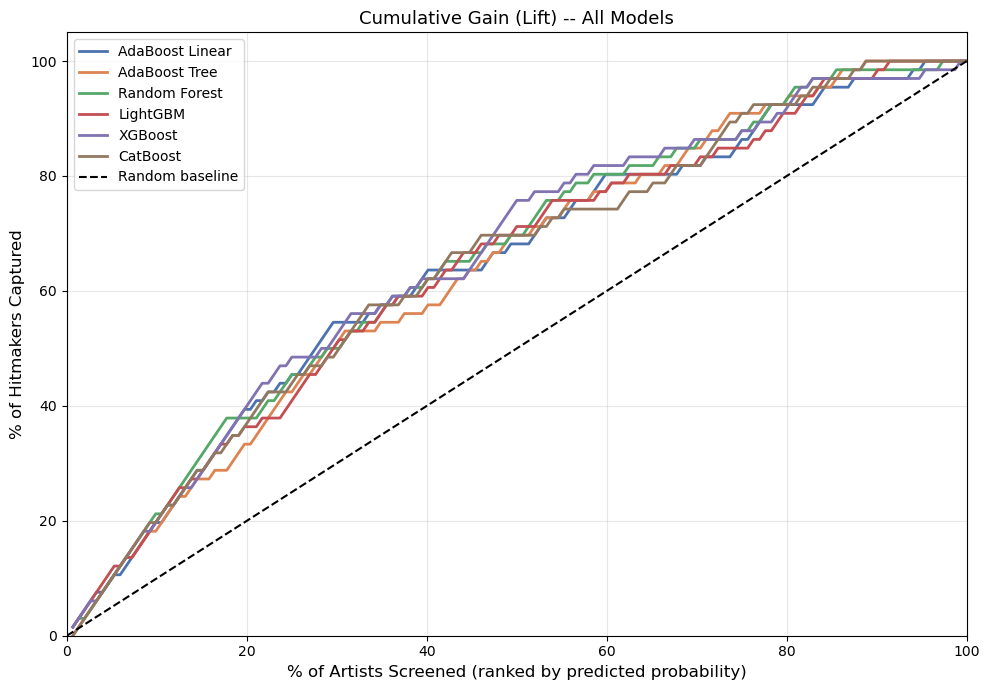


Model                       @10%      @20%      @30%      @50%
------------------------------------------------------------
AdaBoost Linear            1.87x     1.93x     1.80x     1.36x
AdaBoost Tree              1.87x     1.63x     1.70x     1.39x
Random Forest              2.02x     1.86x     1.65x     1.39x
LightGBM                   2.02x     1.78x     1.70x     1.42x
XGBoost                    2.02x     2.01x     1.75x     1.52x
CatBoost                   2.02x     1.86x     1.65x     1.39x


In [84]:
# Overlaying all 6 lift curves on one plot allows direct visual comparison of
# how quickly each model concentrates real hitmakers at the top of its ranking.
# A steeper initial curve = the model is better at prioritising true hitmakers.
# Also prints lift at key screening percentiles (10%, 20%, 30%, 50%) for a
# concrete, stakeholder-friendly summary: 'Model X finds 2.4x more hitmakers
# than random when screening the top 20% of artists.'

fig, ax = plt.subplots(figsize=(10, 7))
for name in MODEL_NAMES:
    y_p = PIPE[name]['y_proba_te']
    pop_frac, gain, _ = compute_lift(y_test.values, y_p)
    ax.plot(pop_frac * 100, gain * 100, lw=2, label=name, color=c_map[name])
ax.plot([0, 100], [0, 100], 'k--', lw=1.5, label='Random baseline')
ax.set_xlabel('% of Artists Screened (ranked by predicted probability)', fontsize=12)
ax.set_ylabel('% of Hitmakers Captured', fontsize=12)
ax.set_title('Cumulative Gain (Lift) -- All Models', fontsize=13)
ax.legend(fontsize=10); ax.grid(True, alpha=0.3)
ax.set_xlim(0, 100); ax.set_ylim(0, 105)
plt.tight_layout(); plt.show()

print(f'\n{"Model":<22}  {"@10%":>8}  {"@20%":>8}  {"@30%":>8}  {"@50%":>8}')
print('-' * 60)
for name in MODEL_NAMES:
    y_p = PIPE[name]['y_proba_te']
    pop_frac, gain, lift = compute_lift(y_test.values, y_p)
    lifts = []
    for pct in [0.10, 0.20, 0.30, 0.50]:
        idx = min(np.searchsorted(pop_frac, pct), len(lift) - 1)
        lifts.append(lift[idx])
    print(f'{name:<22}  {lifts[0]:>7.2f}x  {lifts[1]:>7.2f}x  {lifts[2]:>7.2f}x  {lifts[3]:>7.2f}x')

In [36]:
# Cross-model prediction table showing which test artists the models disagree on most.
# Disagreement = standard deviation of predicted probabilities across all 6 models.
# High-disagreement artists where models split (some predict hitmaker, others don't)
# are the most informative cases for understanding model differences.
# These will be the focus of the SHAP waterfall analysis in the explainability
# notebook (ml_sandbox_22), run after reviewing these results.

short_names = [n[:12] for n in MODEL_NAMES]
all_probas  = {short: PIPE[name]['y_proba_te']
               for short, name in zip(short_names, MODEL_NAMES)}

df_pred_compare = pd.DataFrame(all_probas, index=y_test.index).round(3)
df_pred_compare['True Label']   = y_test.values
df_pred_compare['True Class']   = y_test.map({0.0: 'One-hit Wonder', 1.0: 'Hitmaker'}).values
df_pred_compare['Disagreement'] = df_pred_compare[short_names].std(axis=1).round(3)
df_pred_compare = df_pred_compare.sort_values('Disagreement', ascending=False)

print('Top 20 most disagreed-upon test artists (candidates for SHAP waterfall analysis):')
print(df_pred_compare.head(20).to_string())
print('\nBottom 10 most agreed-upon:')
print(df_pred_compare.tail(10).to_string())

Top 20 most disagreed-upon test artists (candidates for SHAP waterfall analysis):
     AdaBoost Lin  AdaBoost Tre  Random Fores  LightGBM  XGBoost  CatBoost  True Label      True Class  Disagreement
589         0.881         0.203         0.423     0.439    0.275     0.441         0.0  One-hit Wonder         0.236
103         0.849         0.291         0.492     0.439    0.462     0.506         1.0        Hitmaker         0.185
37          0.183         0.622         0.670     0.510    0.676     0.563         1.0        Hitmaker         0.185
146         0.155         0.676         0.535     0.586    0.397     0.429         0.0  One-hit Wonder         0.182
87          0.137         0.622         0.535     0.510    0.281     0.452         0.0  One-hit Wonder         0.180
605         0.126         0.622         0.557     0.510    0.363     0.425         0.0  One-hit Wonder         0.177
656         0.151         0.622         0.617     0.510    0.560     0.460         0.0  One-hit Won

AdaBoost Tree: SHAP failed (Model type not yet supported by TreeExplainer: <class 'sklearn.ensemble._weight_boosting.AdaBoostClassifier'>), falling back to perm importance


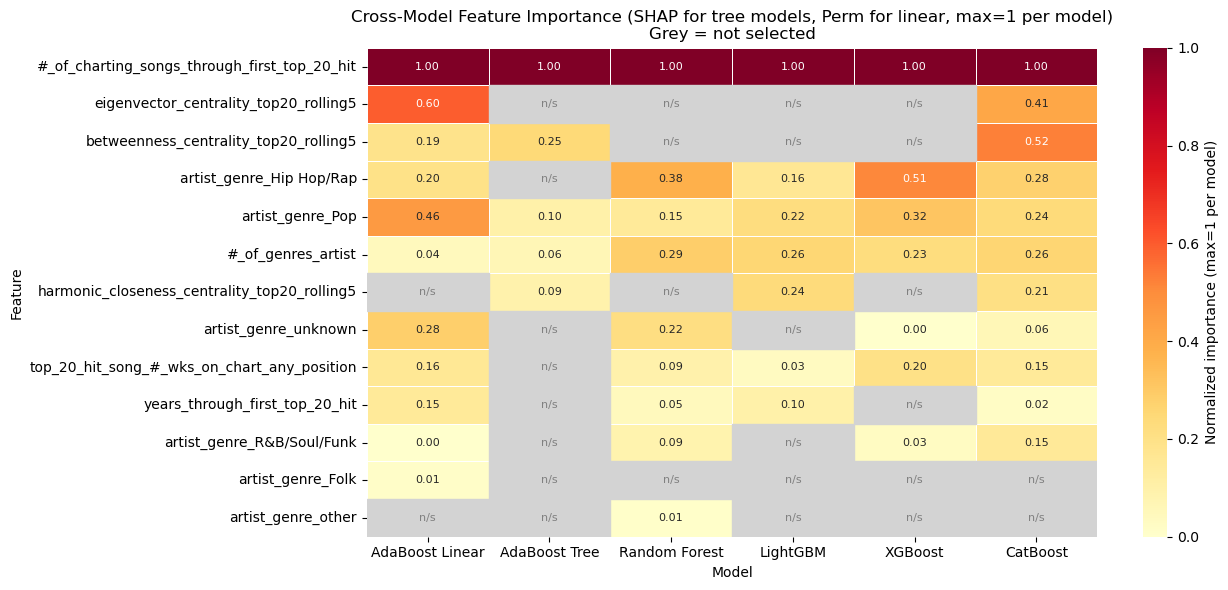

In [85]:
# Cross-model feature importance heatmap.
# For tree-based models we use SHAP mean|value| as the importance measure:
# it captures non-linear interactions directly from the tree structure and
# is more reliable than permutation importance for correlated features.
# For AdaBoost Linear (SGDClassifier), permutation importance is used.
# SHAP is computed once here on X_train_final and stored in PIPE for reuse
# in the signed heatmap below.
# Normalization: max=1 per model column so the most important feature in each
# model equals 1 -- makes visual comparison across models meaningful.
# Grey = feature not selected by that model.

TREE_MODEL_NAMES_H = {'AdaBoost Tree', 'Random Forest', 'LightGBM', 'XGBoost', 'CatBoost'}

# Compute SHAP on final feature set for tree models
for name in MODEL_NAMES:
    if name in TREE_MODEL_NAMES_H:
        try:
            model = PIPE[name]['model_final']
            X_tr  = PIPE[name]['X_train_final']
            explainer = shap.TreeExplainer(model)
            sv = explainer.shap_values(X_tr)
            if isinstance(sv, list):
                sv = sv[1]
            elif sv.ndim == 3:
                sv = sv[:, :, 1]
            PIPE[name]['shap_final_abs']    = pd.Series(np.abs(sv).mean(axis=0), index=X_tr.columns)
            PIPE[name]['shap_final_signed'] = pd.Series(sv.mean(axis=0),          index=X_tr.columns)
        except Exception as e:
            print(f'{name}: SHAP failed ({e}), falling back to perm importance')
            PIPE[name]['shap_final_abs']    = None
            PIPE[name]['shap_final_signed'] = None
    else:
        PIPE[name]['shap_final_abs']    = None
        PIPE[name]['shap_final_signed'] = None

all_feats = sorted(set(
    feat for name in MODEL_NAMES
    for feat in PIPE[name]['X_train_final'].columns
))

df_imp = pd.DataFrame(index=all_feats, columns=MODEL_NAMES, dtype=float)
for name in MODEL_NAMES:
    if name in TREE_MODEL_NAMES_H and PIPE[name]['shap_final_abs'] is not None:
        imp = PIPE[name]['shap_final_abs']
    else:
        imp = PIPE[name]['perm_final'].set_index('Feature')['Importance']
    for feat in all_feats:
        df_imp.loc[feat, name] = imp.get(feat, np.nan)

# Normalize: max=1 per model
df_clipped = df_imp.clip(lower=0)
df_norm    = df_clipped.div(df_clipped.max(axis=0), axis=1)
df_norm['_mean'] = df_norm.mean(axis=1)
df_norm = df_norm.sort_values('_mean', ascending=False).drop(columns='_mean')

fig, ax = plt.subplots(figsize=(13, max(6, len(all_feats) * 0.45)))
mask = df_norm.isna()
sns.heatmap(df_norm.astype(float), annot=True, fmt='.2f', cmap='YlOrRd',
            linewidths=0.5, ax=ax, mask=mask,
            cbar_kws={'label': 'Normalized importance (max=1 per model)'},
            vmin=0, vmax=1, annot_kws={'size': 8})
for (i, j) in zip(*np.where(df_norm.isna().values)):
    ax.add_patch(plt.Rectangle((j, i), 1, 1, fill=True, color='lightgrey', zorder=3))
    ax.text(j + 0.5, i + 0.5, 'n/s', ha='center', va='center', fontsize=8, color='gray')
ax.set_title(
    'Cross-Model Feature Importance (SHAP for tree models, Perm for linear, max=1 per model)\nGrey = not selected',
    fontsize=12,
)
ax.set_xlabel('Model'); ax.set_ylabel('Feature')
plt.tight_layout(); plt.show()


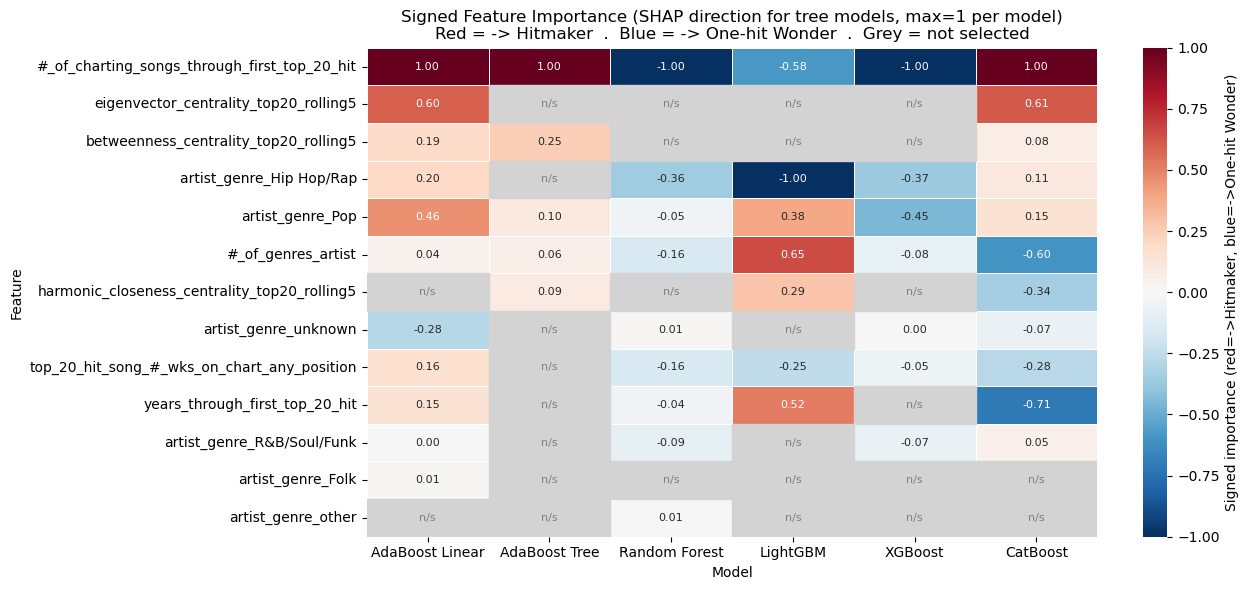

In [87]:
# Signed feature importance heatmap.
# For tree-based models, we use mean SHAP value (with sign) per feature:
#   positive SHAP = feature pushes prediction toward Hitmaker
#   negative SHAP = feature pushes prediction toward One-hit Wonder
# This is more principled than perm * sign(corr) because SHAP direction is
# derived directly from the model's decision structure, not a post-hoc
# correlation with the target.
# For AdaBoost Linear, perm * sign(corr(feature, target)) is used as before.
# Normalization: max absolute value = 1 per model.
# Features that flip sign across models signal non-linear or context-dependent
# relationships -- worth investigating in the SHAP waterfall analysis.

df_signed = pd.DataFrame(index=all_feats, columns=MODEL_NAMES, dtype=float)
for name in MODEL_NAMES:
    X_tr = PIPE[name]['X_train_final']
    if name in TREE_MODEL_NAMES_H and PIPE[name]['shap_final_signed'] is not None:
        # SHAP mean value already encodes direction
        signed_imp = PIPE[name]['shap_final_signed']
        for feat in all_feats:
            if feat in signed_imp.index:
                df_signed.loc[feat, name] = signed_imp[feat]
    else:
        # AdaBoost Linear: perm importance * sign(corr with target)
        imp = PIPE[name]['perm_final'].set_index('Feature')['Importance']
        for feat in all_feats:
            if feat in X_tr.columns and feat in imp.index:
                corr = np.corrcoef(X_tr[feat].values, y_train.values)[0, 1]
                df_signed.loc[feat, name] = imp[feat] * np.sign(corr)

# Normalize: max absolute value = 1 per model
abs_max        = df_signed.abs().max(axis=0)
df_signed_norm = df_signed.div(abs_max, axis=1)
df_signed_norm = df_signed_norm.reindex(df_norm.index)  # same row order as unsigned heatmap

fig, ax = plt.subplots(figsize=(13, max(6, len(all_feats) * 0.45)))
mask_s = df_signed_norm.isna()
sns.heatmap(df_signed_norm.astype(float), annot=True, fmt='.2f', cmap='RdBu_r',
            linewidths=0.5, ax=ax, mask=mask_s,
            cbar_kws={'label': 'Signed importance (red=->Hitmaker, blue=->One-hit Wonder)'},
            vmin=-1, vmax=1, annot_kws={'size': 8})
for (i, j) in zip(*np.where(df_signed_norm.isna().values)):
    ax.add_patch(plt.Rectangle((j, i), 1, 1, fill=True, color='lightgrey', zorder=3))
    ax.text(j + 0.5, i + 0.5, 'n/s', ha='center', va='center', fontsize=8, color='gray')
ax.set_title(
    'Signed Feature Importance (SHAP direction for tree models, max=1 per model)\n'
    'Red = -> Hitmaker  .  Blue = -> One-hit Wonder  .  Grey = not selected',
    fontsize=12,
)
ax.set_xlabel('Model'); ax.set_ylabel('Feature')
plt.tight_layout(); plt.show()
